# **DATA 221: Final Project Code**

## **Part A: Data Wrangling**

### **1. Data Collection**

For this project, I built a country–year panel dataset covering roughly 50 countries from 2008 to 2020. **I use annual mean PM2.5 (EN.ATM.PM25.MC.M3) as the air quality measure.**

All other variables come from the World Bank Development Indicators to keep everything at the country level and consistent across time. I selected 14 variables that represent environmental, economic, and social aspects of sustainability while also checking that data coverage was strong across countries. I got 154 countries in total before pre-processing. 

Due to rate limits and timeout errors, I separated my code into three different runs, and then aggregated the results into one single csv file, `clean_interpolated_panel.csv`. Below is the code that I ran to get my data: 


``` python
import requests
import pandas as pd
import time

START_YEAR = 2008
END_YEAR = 2020

# COUNTRIES = [
#     "USA","CAN","GBR","DEU","FRA","ITA","ESP","JPN","KOR","IND",
#     "BRA","MEX","AUS","NLD","SWE","NOR","ZAF","ARG","TUR","IDN",
#     "CHE","POL","BEL","AUT","DNK","FIN","IRL","PRT","GRC","NZL",
#     "CHN","THA","MYS","PHL","VNM","EGY","SAU","ARE","ISR","COL",
#     "PER","CHL","CZE","HUN","ROU","UKR","PAK","BGD","NGA","KEN"
# ]
# COUNTRIES = [
#     "GTM","BLZ","SLV","HND","NIC","CRI","PAN",
#     "CUB","DOM","HTI","JAM","TTO","BHS","BRB",
#     "URY","PRY","ECU","BOL","VEN","GUY","SUR",
#     "LUX","ISL","SVK","BGR","HRV","SVN","SRB",
#     "MDA","BLR","EST","LVA","LTU","GEO","ARM",
#     "KHM","LAO","MMR","BRN","TLS","SGP", "LKA",
#     "LBN","QAT","KWT","OMN","BHR","YEM", "MAR",
# ]
COUNTRIES = [
"KAZ","UZB","TKM","KGZ","TJK","NPL","BTN","MDV",
"IRN","IRQ","JOR","TUN","DZA","LBY",
"ETH","GHA","TZA","UGA","RWA","SEN","CIV",
"ZMB","ZWE","MWI","MOZ","AGO","NAM","BWA",
"CMR","GAB","COG","COD","MLI","NER","BEN",
"TGO","GIN","SLE","LBR","MDG",
"ALB","MKD","BIH","MNE","MNG","PNG","FJI","SLB","WSM",
"ATG","DMA","GRD","KNA","LCA","VCT","HND","NIC"
]


# See Legend description in the next cell
INDICATORS = {
    "EN.ATM.PM25.MC.M3": "pm25",
    "EG.EGY.PRIM.PP.KD": "primary_energy_per_capita",
    "EG.FEC.RNEW.ZS": "renewable_energy_pct",
    "AG.LND.FRST.ZS": "forest_area_pct",
    "EG.USE.PCAP.KG.OE": "energy_use_per_capita",
    "AG.LND.AGRI.ZS": "agricultural_land_pct",
    "NY.GDP.PCAP.KD": "gdp_per_capita",
    "NV.IND.TOTL.ZS": "industry_pct_gdp",
    "NE.TRD.GNFS.ZS": "trade_pct_gdp",
    "NE.GDI.TOTL.ZS": "gross_capital_formation_pct",
    "SP.URB.TOTL.IN.ZS": "urban_population_pct",
    "SP.DYN.LE00.IN": "life_expectancy",
    "EN.POP.DNST": "population_density",
    "SH.H2O.BASW.ZS": "basic_drinking_water_pct",
}

BASE = "https://api.worldbank.org/v2/country/{countries}/indicator/{indicator}"


def fetch_indicator(indicator_code, countries_iso3, chunk_size=20):

    all_frames = []

    for i in range(0, len(countries_iso3), chunk_size):

        batch = countries_iso3[i:i+chunk_size]
        countries_str = ";".join(batch)

        params = {
            "format": "json",
            "per_page": 20000,
            "date": f"{START_YEAR}:{END_YEAR}"
        }

        url = BASE.format(countries=countries_str, indicator=indicator_code)

        try:
            r = requests.get(url, params=params, timeout=120)
            r.raise_for_status()
            payload = r.json()

            if isinstance(payload, list) and payload[1] is not None:
                rows = []
                for item in payload[1]:
                    rows.append({
                        "country": item["countryiso3code"],
                        "year": int(item["date"]),
                        "value": item["value"]
                    })

                all_frames.append(pd.DataFrame(rows))

        except requests.exceptions.RequestException:
            print("Failed batch:", batch)

        time.sleep(1)

    if all_frames:
        return pd.concat(all_frames, ignore_index=True)
    else:
        return pd.DataFrame(columns=["country","year","value"])

dfs = []

for code, name in INDICATORS.items():
    print(f"Fetching {code}")
    dfi = fetch_indicator(code, COUNTRIES)
    dfi = dfi.rename(columns={"value": name})
    dfs.append(dfi)
    time.sleep(0.5)

df = dfs[0]
for dfi in dfs[1:]:
    df = df.merge(dfi, on=["country","year"], how="outer")

df = df.sort_values(["country","year"]).reset_index(drop=True)

print(df.head())
print("\nMissing values:")
print(df.isna().sum())

df.to_csv("clean_8_variable_panel_3.csv", index=False)
```

### **Variable Legend**

**pm25 (EN.ATM.PM25.MC.M3)**
Annual average PM2.5 concentration. This is the main air quality outcome and serves as the pollution measure throughout the project.


### Environmental

**primary_energy_per_capita (EG.EGY.PRIM.PP.KD)**: Captures overall energy intensity and resource use.

**renewable_energy_pct (EG.FEC.RNEW.ZS)**: Share of energy coming from renewable sources, indicating cleaner energy transition.

**forest_area_pct (AG.LND.FRST.ZS)**: Forest coverage as a share of land area, reflecting environmental protection and natural assets.

**energy_use_per_capita (EG.USE.PCAP.KG.OE)**: Overall energy consumption per person, often linked to environmental pressure.

**agricultural_land_pct (AG.LND.AGRI.ZS)**: Land use for agriculture, which relates to resource use and environmental structure.


### Economic


**gdp_per_capita (NY.GDP.PCAP.KD)**: Overall economic development level.

**industry_pct_gdp (NV.IND.TOTL.ZS)**: Share of output coming from industry, often tied to emissions and energy use.

**trade_pct_gdp (NE.TRD.GNFS.ZS)**: Trade as a percentage of GDP. This shows economic openness and integration into global markets.

**gross_capital_formation_pct (NE.GDI.TOTL.ZS)**: Gross capital formation as a percentage of GDP. It shows investment activity and long-run development capacity.


### Social / Urban

**urban_population_pct (SP.URB.TOTL.IN.ZS)**: Level of urbanization.

**life_expectancy (SP.DYN.LE00.IN)**: Life expectancy at birth. It is a general measure of population health and development.

**population_density (EN.POP.DNST)**: How concentrated the population is geographically.

**basic_drinking_water_pct (SH.H2O.BASW.ZS)**: Access to basic drinking water. 

### **2. Merging and Cleaning**

Here, I dropped all countries with no data in a given variable. I ended up dropping 27 countries.

In [123]:
import pandas as pd 

df = pd.read_csv("clean_full_panel.csv")

cols_to_check = [col for col in df.columns if col not in ["country", "year"]]

countries_to_drop = []

for country, group in df.groupby("country"):

    for col in cols_to_check:
        if group[col].isna().all():
            countries_to_drop.append(country)
            break 

df_clean = df[~df["country"].isin(countries_to_drop)].copy()

print("Dropped countries:", len(countries_to_drop))
print("Remaining countries:", df_clean["country"].nunique())
print(sorted(countries_to_drop))

Dropped countries: 27
Remaining countries: 127
['ATG', 'BHS', 'BLZ', 'BRB', 'BTN', 'DMA', 'FJI', 'GIN', 'GRD', 'GUY', 'JAM', 'KNA', 'LBR', 'LCA', 'MDV', 'MLI', 'MMR', 'MWI', 'NGA', 'NIC', 'PNG', 'SLB', 'SLE', 'TLS', 'TTO', 'VCT', 'WSM']


In [124]:
df_clean.isna().sum()

country                         0
year                            0
pm25                            0
primary_energy_per_capita       0
renewable_energy_pct            0
forest_area_pct                 0
energy_use_per_capita           0
agricultural_land_pct           0
gdp_per_capita                  2
industry_pct_gdp               20
trade_pct_gdp                  24
gross_capital_formation_pct    33
urban_population_pct            0
life_expectancy                 0
population_density              0
basic_drinking_water_pct        4
dtype: int64

In [125]:
# Making sure there are no empty columns before we do the interpolation
for country, group in df_clean.groupby("country"):
    for col in df_clean.columns:
        if col not in ["country", "year"]:
            if group[col].isna().all():
                print("Drop:", country, col)

All datasets were merged by country (ISO3 code) and year to create a single panel. Missing values were very limited (around 2% at most for any variable) as the data is mostly collected from World Bank. **Since the data are time series within each country, I used linear interpolation to fill internal gaps.** This makes it consistent with time series data and also avoids potential biases from backward or forward filling. 

I avoided extrapolating beyond observed years and dropped any remaining incomplete rows (which were very few) to keep the final dataset fully observed for modeling.

In [126]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Interpolate missing values by country and year, then drop any remaining missing values (linear interpolation)
df_clean = df_clean.sort_values(["country", "year"])

numeric_cols = df_clean.select_dtypes(include="number").columns

df_clean[numeric_cols] = (
    df_clean.groupby("country")[numeric_cols]
      .apply(lambda g: g.interpolate(method="linear", limit_area="inside"))
      .reset_index(level=0, drop=True)
)

df = df_clean.dropna().reset_index(drop=True)

In [127]:
df.isna().sum()

country                        0
year                           0
pm25                           0
primary_energy_per_capita      0
renewable_energy_pct           0
forest_area_pct                0
energy_use_per_capita          0
agricultural_land_pct          0
gdp_per_capita                 0
industry_pct_gdp               0
trade_pct_gdp                  0
gross_capital_formation_pct    0
urban_population_pct           0
life_expectancy                0
population_density             0
basic_drinking_water_pct       0
dtype: int64

In [128]:
# Save df to a new CSV file for the next steps of the project.
df.to_csv("clean_interpolated_panel.csv", index=False)

### Urban Sustainability Index (USI) Construction

To summarize sustainability, I constructed a composite Urban Sustainability Index (USI) based on three dimensions: environmental, economic, and social. Each variable was scaled to a 0–100 range using min–max normalization so that indicators are comparable. For variables where higher values indicate worse sustainability (e.g., energy use per capita), I inverted the scale so that higher scores consistently reflect better outcomes.

I first averaged indicators within each dimension to create three sub-indices. The final USI is the simple average of the environmental, economic, and social scores. This ensures that no single dimension dominates the overall measure.

In [129]:
df = pd.read_csv("clean_interpolated_panel.csv")

# Selected indicators for USI construction
positive_indicators = [
    'renewable_energy_pct', 
    'forest_area_pct', 
    'basic_drinking_water_pct', 
    'life_expectancy', 
    'gdp_per_capita'
]
negative_indicators = ['energy_use_per_capita']

# Normalized indicators to 0-100 scale
scaler = MinMaxScaler((0, 100))
df_scaled = df.copy()

# Scale positive indicators normally; Scale negative indicators and invert them (so 100 is best, 0 is worst)
df_scaled[positive_indicators] = scaler.fit_transform(df[positive_indicators])

df_scaled[negative_indicators] = scaler.fit_transform(df[negative_indicators])
df_scaled['energy_use_per_capita'] = 100 - df_scaled['energy_use_per_capita']

# Calculate USI (Average of all indicators)
usi_columns = positive_indicators + negative_indicators
df['USI'] = df_scaled[usi_columns].mean(axis=1)

print(df[['country', 'year', 'pm25', 'USI']].head(10))

  country  year       pm25        USI
0     AGO  2008  24.172311  44.034769
1     AGO  2009  24.172024  44.295005
2     AGO  2010  24.178057  45.075983
3     AGO  2011  24.337940  45.510115
4     AGO  2012  24.480493  45.701891
5     AGO  2013  24.538658  46.000209
6     AGO  2014  23.945584  46.793410
7     AGO  2015  25.002150  47.254700
8     AGO  2016  25.180701  48.014379
9     AGO  2017  23.959151  49.300761


We see that the values are within a reasonable range and the distribution looks sensible, with some variation across countries and over time.

In [130]:
df["USI"].describe()

count    1611.000000
mean       53.431637
std         7.714157
min        30.619401
25%        47.026310
50%        54.148031
75%        58.831578
max        75.425202
Name: USI, dtype: float64

Confirming that there are no missing values in the final dataset. 

## **Part B: Exploratory Data Analysis (EDA)**

### 1. Correlation between USI and Air Quality



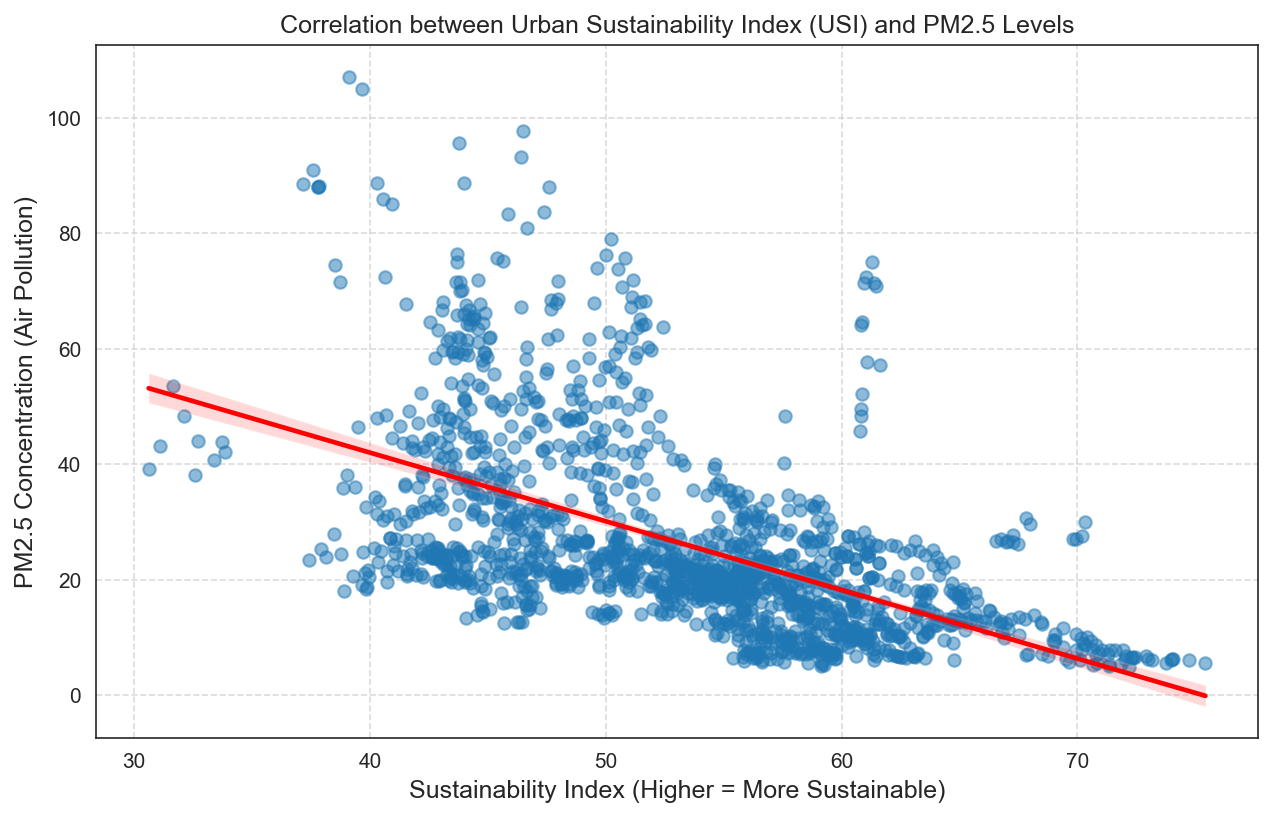

In [131]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='USI', y='pm25', scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Correlation between Urban Sustainability Index (USI) and PM2.5 Levels')
plt.xlabel('Sustainability Index (Higher = More Sustainable)', fontsize=12)
plt.ylabel('PM2.5 Concentration (Air Pollution)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
# plt.show()

plt.savefig('f1.png', dpi=600)

This scatter plot confirms a clear "green dividend": **as cities improve their sustainability index, air quality follows suit**. We see a sharp drop in PM 2.5 as countries move from a USI of 40 toward 70. The tight shading around the red trend line shows this is a consistent pattern. If a city wants to breathe easier, the data suggests that hitting a USI score of at least 65 is the "sweet spot" where pollution levels finally stabilize at safer levels.

### 2. Correlation between USI and Air Quality

From 2008 to 2020, the average sustainability index increases fairly steadily. The rise is gradual, with no sharp jumps, but the overall direction is clearly upward. Over the same period, average PM2.5 levels move around in the earlier years and peak around the mid 2010s, then trend downward, especially after 2018. By 2020, pollution levels are noticeably lower than in the middle of the sample. Overall, the figure suggests that sustainability has improved over time, while air pollution has generally declined in the later years.

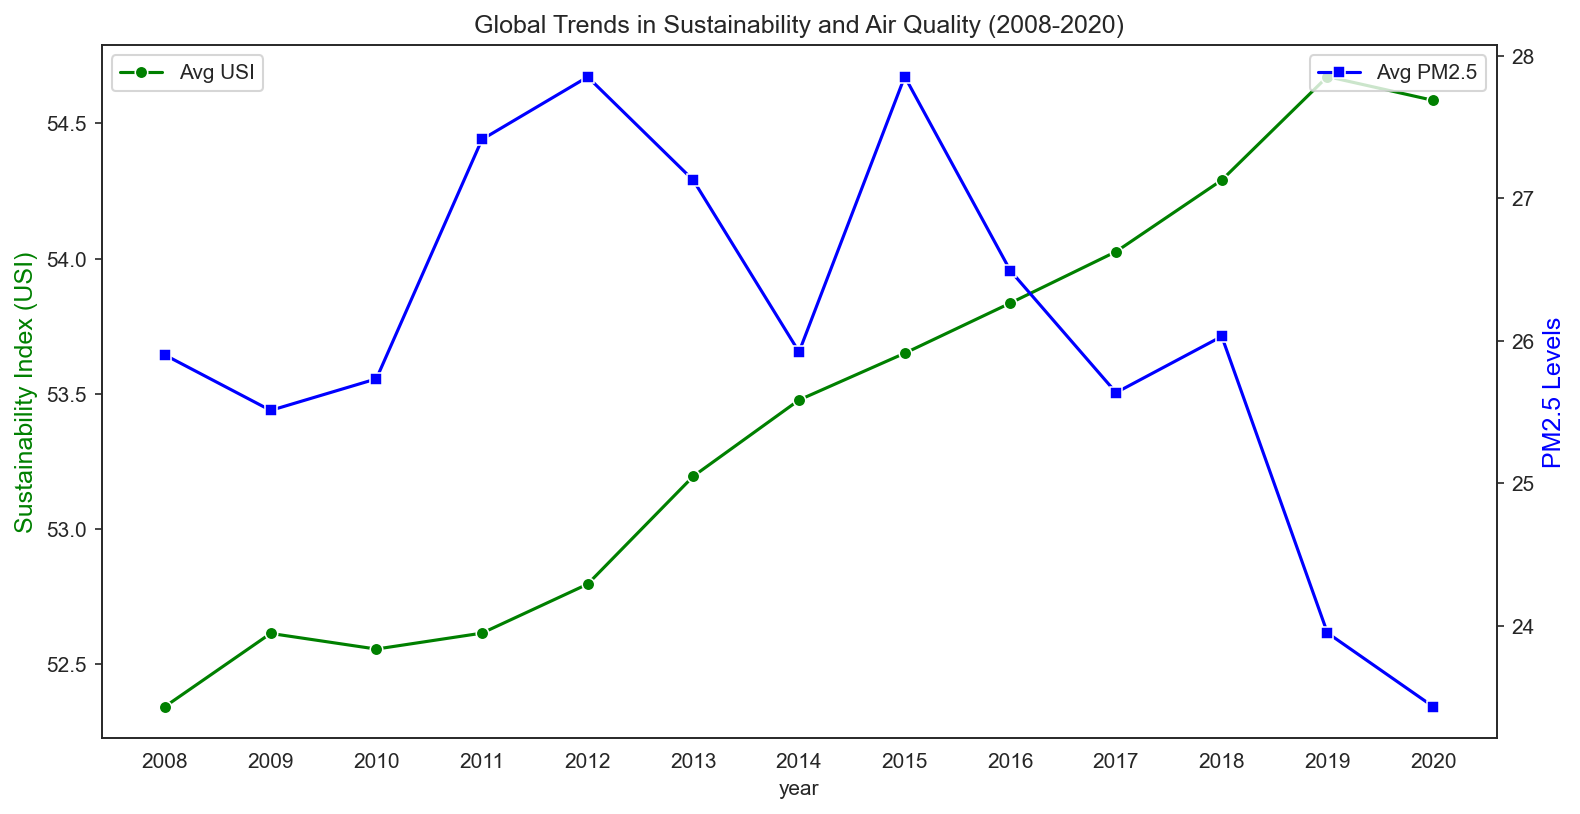

In [132]:
yearly_avg = df.groupby('year')[['pm25', 'USI']].mean().reset_index()

fig, ax1 = plt.subplots(figsize=(12, 6))

ax2 = ax1.twinx()
sns.lineplot(data=yearly_avg, x='year', y='USI', ax=ax1, color='green', marker='o', label='Avg USI')
sns.lineplot(data=yearly_avg, x='year', y='pm25', ax=ax2, color='blue', marker='s', label='Avg PM2.5')

ax1.set_ylabel('Sustainability Index (USI)', color='green', fontsize=12)
ax2.set_ylabel('PM2.5 Levels', color='blue', fontsize=12)
plt.title('Global Trends in Sustainability and Air Quality (2008-2020)')
plt.xticks(range(2008, 2021))
# plt.show()
plt.savefig('f2.png', dpi=600)

### 3. Top 10 vs. Bottom 10 Countries in 2020

The bar chart really puts the global inequality of sustainability into perspective. By splitting the top and bottom performers, we see a massive 40-point gap between leaders like Switzerland and Norway versus countries still in the early stages of industrialization. The vertical dashed line shows the global average; notice how the "Top 10" are all comfortably clustered in the 70s, while the "Bottom 10" are fighting to even reach a score of 50. 

Something worth noting is that Gabon, a developing country but with significant natural resources, is in the "Top 10" group. This suggests that while economic development often correlates with sustainability, there are exceptions where countries can leverage their natural assets to achieve better outcomes even without being highly industrialized.

/var/folders/vp/npcvxcc52xqfjgmswcdds6yc0000gn/T/ipykernel_32856/4154613197.py:25: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




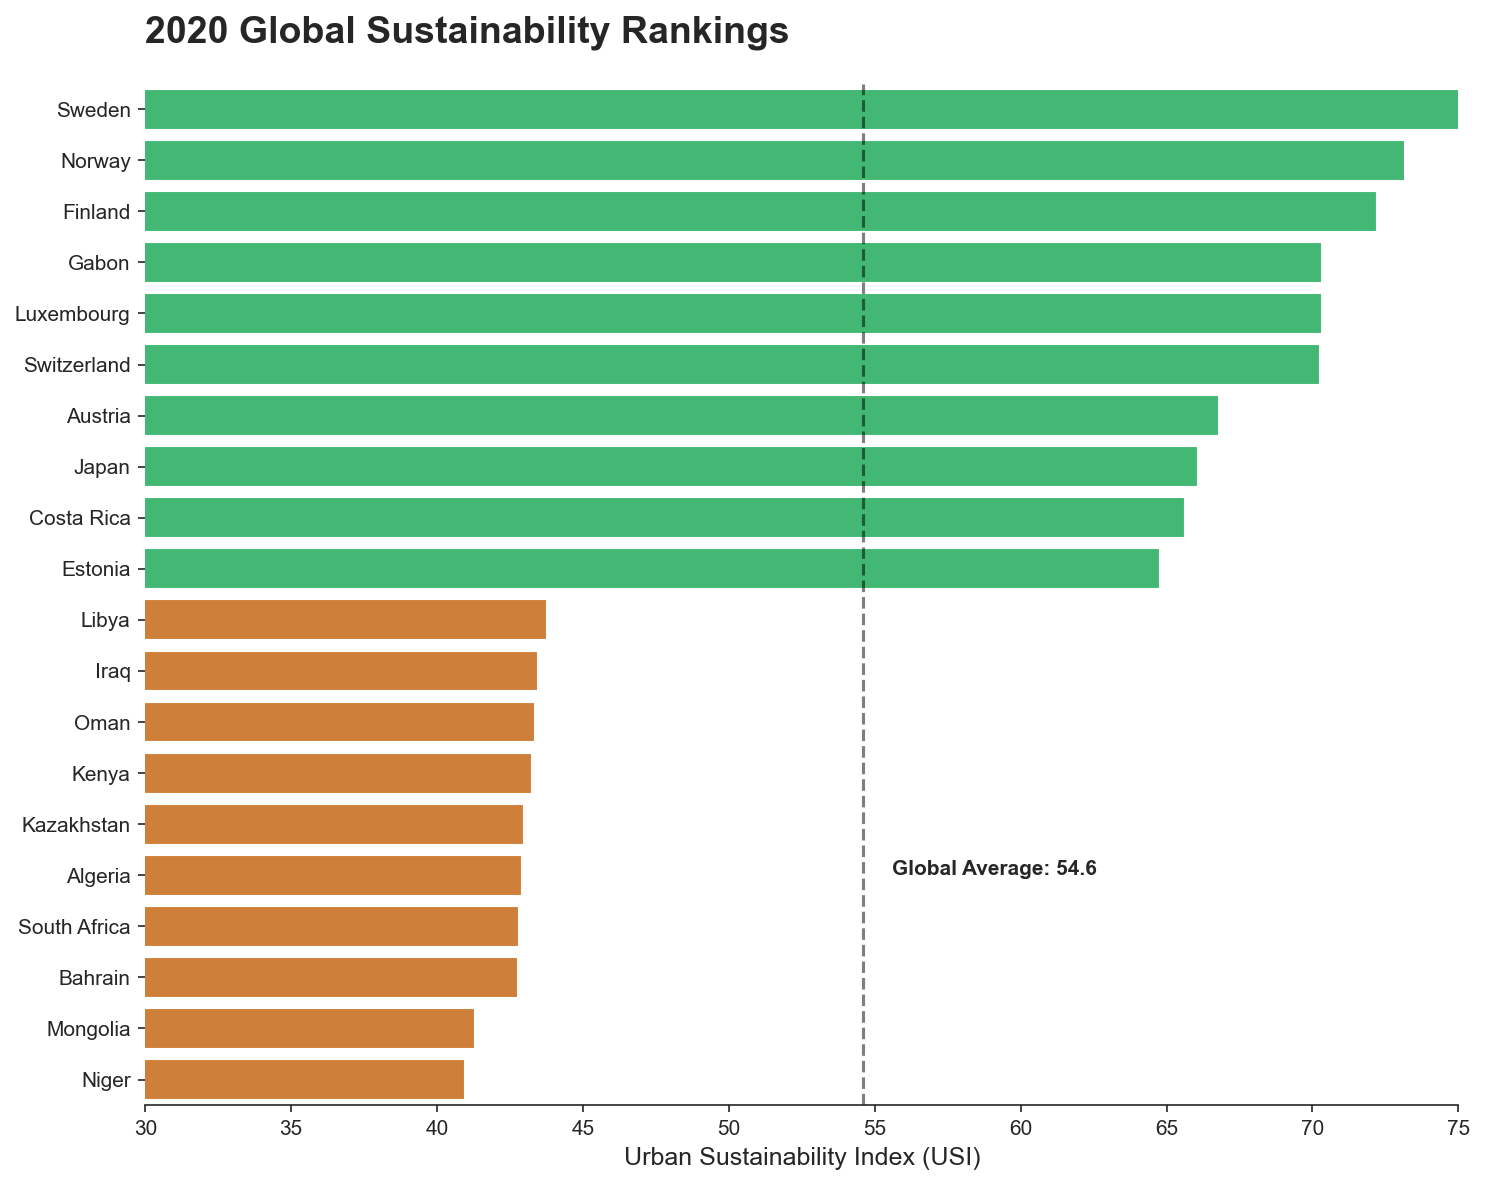

In [133]:
iso_to_name = {
    'CHE': 'Switzerland', 'NOR': 'Norway', 'SWE': 'Sweden', 'FIN': 'Finland', 
    'DNK': 'Denmark', 'AUT': 'Austria', 'IRL': 'Ireland', 'DEU': 'Germany', 
    'NLD': 'Netherlands', 'CAN': 'Canada', 'IND': 'India', 'PAK': 'Pakistan', 
    'BGD': 'Bangladesh', 'NGA': 'Nigeria', 'EGY': 'Egypt', 'VNM': 'Vietnam', 
    'PHL': 'Philippines', 'IDN': 'Indonesia', 'KEN': 'Kenya', 'ARE': 'UAE', 
    'GAB': 'Gabon', 'LUX': 'Luxembourg', 'JPN': 'Japan', 'CRI': 'Costa Rica', 
    'EST': 'Estonia', 'LBY': 'Libya', 'IRQ': 'Iraq', 'OMN': 'Oman', 
    'KAZ': 'Kazakhstan', 'DZA': 'Algeria', 'ZAF': 'South Africa', 
    'BHR': 'Bahrain','MNG': 'Mongolia', 'NER': 'Niger'
}

latest = df[df['year'] == 2020].copy()
latest['full_name'] = latest['country'].map(iso_to_name).fillna(latest['country'])

top_10 = latest.nlargest(10, 'USI')
bottom_10 = latest.nsmallest(10, 'USI')
combined = pd.concat([top_10, bottom_10]).sort_values('USI', ascending=False)

plt.figure(figsize=(10, 8), dpi=150)
sns.set_style("ticks")

colors = ["#2ecc71" if x in top_10.full_name.values else "#e67e22" for x in combined.full_name]

ax = sns.barplot(data=combined, x='USI', y='full_name', palette=colors)

avg_val = latest['USI'].mean()
plt.axvline(avg_val, color='black', linestyle='--', alpha=0.5)
plt.text(avg_val + 1, 15, f'Global Average: {avg_val:.1f}', fontweight='bold')


plt.xlim(30, 75) 
plt.title('2020 Global Sustainability Rankings', loc='left', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Urban Sustainability Index (USI)', fontsize=12)
plt.ylabel('') 
sns.despine(left=True)
plt.tight_layout()
# plt.show()
plt.savefig('f3.png', dpi=600)

### 4 & 5. Regional Trends for PM2.5 and USI

When we break down the data by region, the "Air Quality Gap" becomes striking. While most regions have seen gradual improvements since 2008, Asia and Africa remain in a different league of pollution exposure. The good news is the visible decline in Asian PM 2.5 levels over the last decade, which suggests that the link between industrial growth and poor air quality can be broken. On the other end, Europe and North America show that once a certain level of sustainability is reached, air quality remains consistently high with very little annual fluctuation.


The USI trends show that sustainability isn't just a "rich country" goal, as almost every region has seen its score improve since 2008. Europe remains the global benchmark, but the Middle East and Asia are closing the gap the fastest. The data shows that while PM 
2.5 is a "lagging" indicator that takes time to improve, the USI components (like renewable energy and life expectancy) are moving in the right direction globally.

<>:26: SyntaxWarning:

invalid escape sequence '\m'

<>:26: SyntaxWarning:

invalid escape sequence '\m'

/var/folders/vp/npcvxcc52xqfjgmswcdds6yc0000gn/T/ipykernel_32856/791636649.py:26: SyntaxWarning:

invalid escape sequence '\m'



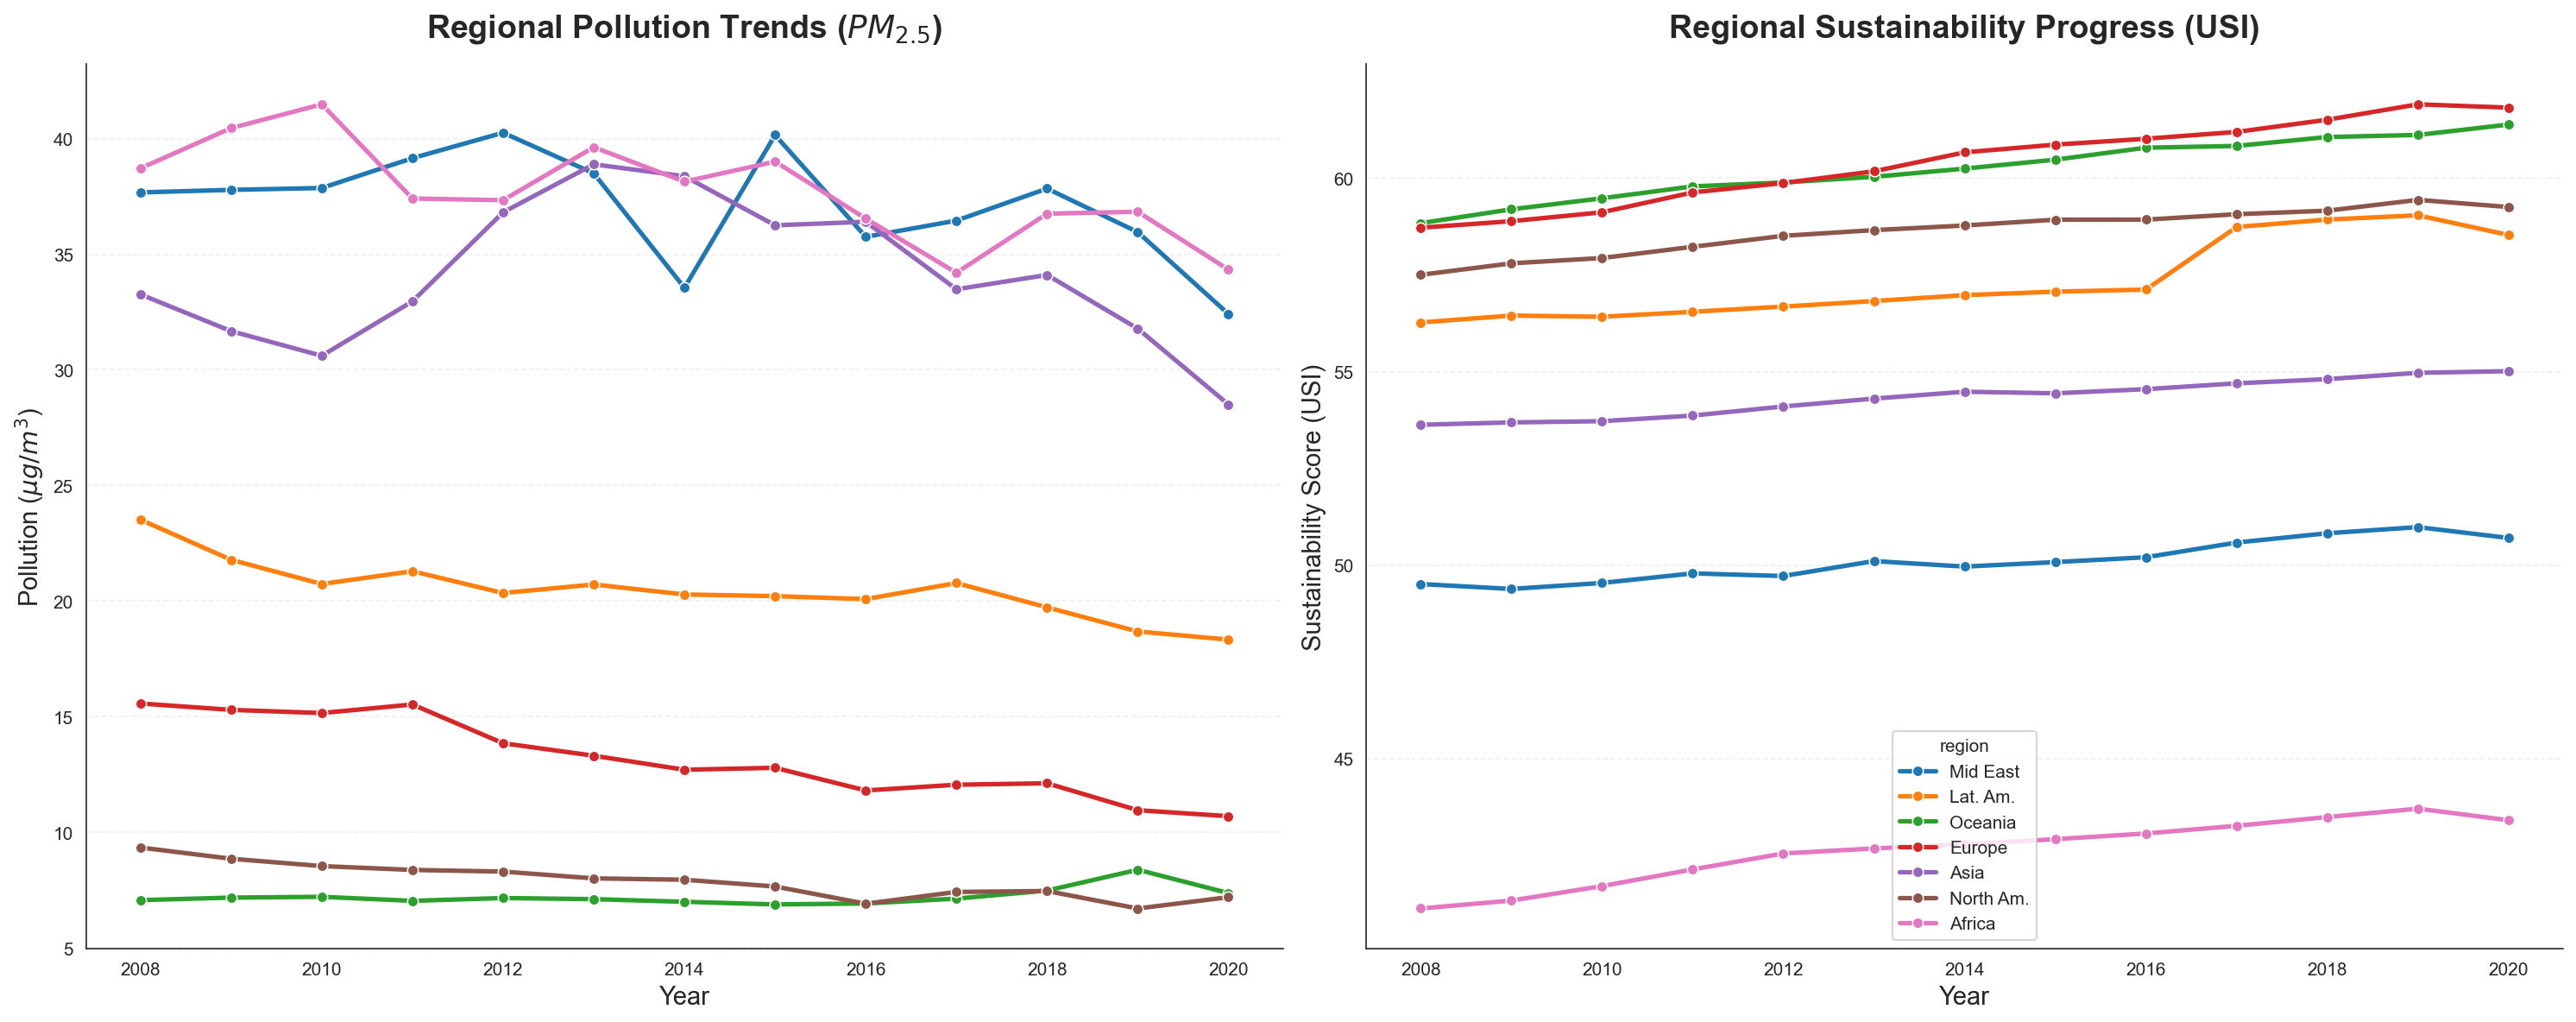

In [134]:
region_map = {
    'USA': 'North Am.', 'CAN': 'North Am.',
    'GBR': 'Europe', 'DEU': 'Europe', 'FRA': 'Europe', 'ITA': 'Europe', 'ESP': 'Europe', 
    'NLD': 'Europe', 'SWE': 'Europe', 'NOR': 'Europe', 'CHE': 'Europe', 'POL': 'Europe', 
    'BEL': 'Europe', 'AUT': 'Europe', 'DNK': 'Europe', 'FIN': 'Europe', 'IRL': 'Europe', 
    'PRT': 'Europe', 'GRC': 'Europe', 'CZE': 'Europe', 'HUN': 'Europe', 'ROU': 'Europe',
    'JPN': 'Asia', 'KOR': 'Asia', 'IND': 'Asia', 'CHN': 'Asia', 'THA': 'Asia', 
    'MYS': 'Asia', 'PHL': 'Asia', 'VNM': 'Asia', 'PAK': 'Asia', 'BGD': 'Asia', 'IDN': 'Asia',
    'BRA': 'Lat. Am.', 'MEX': 'Lat. Am.', 'ARG': 'Lat. Am.', 'COL': 'Lat. Am.', 
    'PER': 'Lat. Am.', 'CHL': 'Lat. Am.',
    'AUS': 'Oceania', 'NZL': 'Oceania',
    'ZAF': 'Africa', 'EGY': 'Africa', 'NGA': 'Africa', 'KEN': 'Africa',
    'TUR': 'Mid East', 'SAU': 'Mid East', 'ARE': 'Mid East', 'ISR': 'Mid East'
}

df['region'] = df['country'].map(region_map)

sns.set_style("white")
plt.rcParams['figure.dpi'] = 150

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# LEFT: PM2.5 Trends
sns.lineplot(data=df, x='year', y='pm25', hue='region', marker='o', ax=ax1, linewidth=2.5, errorbar=None)
ax1.set_title('Regional Pollution Trends ($PM_{2.5}$)', fontweight='bold', fontsize=18, pad=15)
ax1.set_ylabel('Pollution ($\mu g/m^3$)', fontsize=14)
ax1.set_xlabel('Year', fontsize=14)
ax1.grid(axis='y', linestyle='--', alpha=0.3)
# Remove the legend from the first plot 
ax1.legend().remove()

# RIGHT: USI Trends
sns.lineplot(data=df, x='year', y='USI', hue='region', marker='o', ax=ax2, linewidth=2.5, errorbar=None)
ax2.set_title('Regional Sustainability Progress (USI)', fontweight='bold', fontsize=18, pad=15)
ax2.set_ylabel('Sustainability Score (USI)', fontsize=14)
ax2.set_xlabel('Year', fontsize=14)
ax2.grid(axis='y', linestyle='--', alpha=0.3)

sns.despine()
plt.tight_layout()
# plt.show()
plt.savefig('f4.png', dpi=600)

## **Part C: Predictive Modeling**

Before doing any modeling, I grouped the data by region to capture regional effects (If I instead use each "country" as a dummy variable, I would have 50+ dummies which would be too many for the sample size). This way, I can control for broad regional differences while still allowing for variation within regions.

In [135]:
region_map = {
    # North America & Caribbean
    "USA": "North Am.", "CAN": "North Am.", "MEX": "North Am.",
    "ATG": "Caribbean", "DMA": "Caribbean", "GRD": "Caribbean", "KNA": "Caribbean", 
    "LCA": "Caribbean", "VCT": "Caribbean", "CUB": "Caribbean", "DOM": "Caribbean", 
    "HTI": "Caribbean", "JAM": "Caribbean", "TTO": "Caribbean", "BHS": "Caribbean", "BRB": "Caribbean",
    
    # Central & Latin America
    "GTM": "Lat. Am.", "BLZ": "Lat. Am.", "SLV": "Lat. Am.", "HND": "Lat. Am.", 
    "NIC": "Lat. Am.", "CRI": "Lat. Am.", "PAN": "Lat. Am.", "BRA": "Lat. Am.", 
    "ARG": "Lat. Am.", "COL": "Lat. Am.", "PER": "Lat. Am.", "CHL": "Lat. Am.",
    "URY": "Lat. Am.", "PRY": "Lat. Am.", "ECU": "Lat. Am.", "BOL": "Lat. Am.", 
    "VEN": "Lat. Am.", "GUY": "Lat. Am.", "SUR": "Lat. Am.",
    
    # Europe & Balkans
    "GBR": "Europe", "DEU": "Europe", "FRA": "Europe", "ITA": "Europe", "ESP": "Europe", 
    "NLD": "Europe", "SWE": "Europe", "NOR": "Europe", "CHE": "Europe", "POL": "Europe", 
    "BEL": "Europe", "AUT": "Europe", "DNK": "Europe", "FIN": "Europe", "IRL": "Europe", 
    "PRT": "Europe", "GRC": "Europe", "CZE": "Europe", "HUN": "Europe", "ROU": "Europe", 
    "UKR": "Europe", "LUX": "Europe", "ISL": "Europe", "SVK": "Europe", "BGR": "Europe", 
    "HRV": "Europe", "SVN": "Europe", "SRB": "Europe", "MDA": "Europe", "BLR": "Europe", 
    "EST": "Europe", "LVA": "Europe", "LTU": "Europe", "ALB": "Europe", "MKD": "Europe", 
    "BIH": "Europe", "MNE": "Europe",
    
    # Asia & Oceania
    "JPN": "Asia", "KOR": "Asia", "IND": "Asia", "CHN": "Asia", "THA": "Asia", 
    "MYS": "Asia", "PHL": "Asia", "VNM": "Asia", "PAK": "Asia", "BGD": "Asia", 
    "IDN": "Asia", "KHM": "Asia", "LAO": "Asia", "MMR": "Asia", "BRN": "Asia", 
    "TLS": "Asia", "SGP": "Asia", "LKA": "Asia", "MNG": "Asia", "NPL": "Asia", 
    "BTN": "Asia", "MDV": "Asia", "KAZ": "Asia", "UZB": "Asia", "TKM": "Asia", 
    "KGZ": "Asia", "TJK": "Asia", "AUS": "Oceania", "NZL": "Oceania", "PNG": "Oceania", 
    "FJI": "Oceania", "SLB": "Oceania", "WSM": "Oceania",
    
    # Middle East & North Africa (MENA)
    "TUR": "MENA", "SAU": "MENA", "ARE": "MENA", "ISR": "MENA", "EGY": "MENA", 
    "LBN": "MENA", "QAT": "MENA", "KWT": "MENA", "OMN": "MENA", "BHR": "MENA", 
    "YEM": "MENA", "MAR": "MENA", "IRN": "MENA", "IRQ": "MENA", "JOR": "MENA", 
    "TUN": "MENA", "DZA": "MENA", "LBY": "MENA", "GEO": "MENA", "ARM": "MENA",
    
    # Sub-Saharan Africa
    "ZAF": "Africa", "NGA": "Africa", "KEN": "Africa", "ETH": "Africa", "GHA": "Africa", 
    "TZA": "Africa", "UGA": "Africa", "RWA": "Africa", "SEN": "Africa", "CIV": "Africa", 
    "ZMB": "Africa", "ZWE": "Africa", "MWI": "Africa", "MOZ": "Africa", "AGO": "Africa", 
    "NAM": "Africa", "BWA": "Africa", "CMR": "Africa", "GAB": "Africa", "COG": "Africa", 
    "COD": "Africa", "MLI": "Africa", "NER": "Africa", "BEN": "Africa", "TGO": "Africa", 
    "GIN": "Africa", "SLE": "Africa", "LBR": "Africa", "MDG": "Africa"
}

df['region'] = df['country'].map(region_map)

# Should return an empty list, meaning all countries were mapped 
print(df[df['region'].isnull()]['country'].unique())

[]


### 1. Baseline LASSO Regression

LASSO RESULTS: All variables
R2 Score: 0.379
Mean Absolute Error: 9.32


/var/folders/vp/npcvxcc52xqfjgmswcdds6yc0000gn/T/ipykernel_32856/647473190.py:62: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




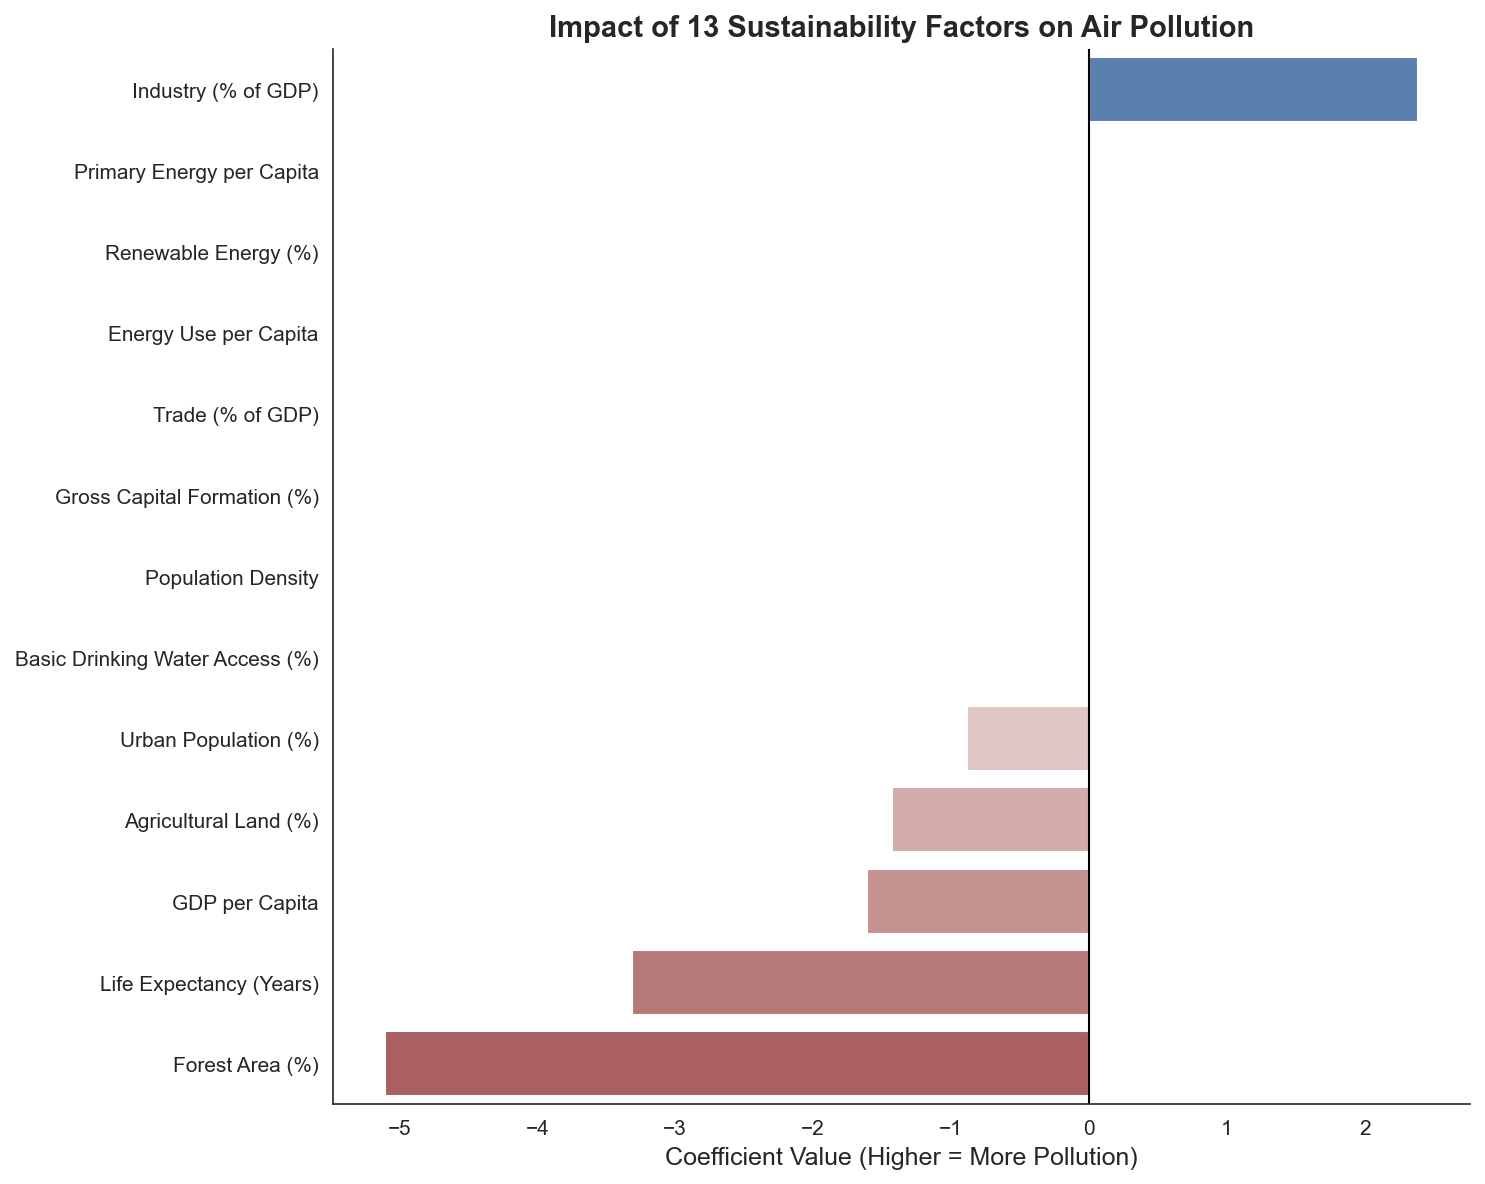

In [136]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_absolute_error, r2_score

feature_labels = {
    'primary_energy_per_capita': 'Primary Energy per Capita',
    'renewable_energy_pct': 'Renewable Energy (%)',
    'forest_area_pct': 'Forest Area (%)',
    'energy_use_per_capita': 'Energy Use per Capita',
    'agricultural_land_pct': 'Agricultural Land (%)',
    'gdp_per_capita': 'GDP per Capita',
    'industry_pct_gdp': 'Industry (% of GDP)',
    'trade_pct_gdp': 'Trade (% of GDP)',
    'gross_capital_formation_pct': 'Gross Capital Formation (%)',
    'urban_population_pct': 'Urban Population (%)',
    'life_expectancy': 'Life Expectancy (Years)',
    'population_density': 'Population Density',
    'basic_drinking_water_pct': 'Basic Drinking Water Access (%)'
}


X_cols = list(feature_labels.keys())

# Drop regions for now
model_df = df[['pm25', 'year'] + X_cols].dropna()

# Time-based Split (2008-2017 Training, 2018-2020 Testing)
train_mask = model_df['year'] <= 2017
test_mask = model_df['year'] > 2017

X_train, X_test = model_df.loc[train_mask, X_cols], model_df.loc[test_mask, X_cols]
y_train, y_test = model_df.loc[train_mask, 'pm25'], model_df.loc[test_mask, 'pm25']

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


lasso = LassoCV(cv=5, random_state=42)
lasso.fit(X_train_scaled, y_train)

y_pred = lasso.predict(X_test_scaled)
print(f"LASSO RESULTS: All variables")
print(f"R2 Score: {r2_score(y_test, y_pred):.3f}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred):.2f}")


coef_df = pd.DataFrame({
    'Feature': X_cols,
    'Coefficient': lasso.coef_
})

coef_df['Feature Name'] = coef_df['Feature'].map(feature_labels)
coef_df = coef_df.sort_values('Coefficient', ascending=False)

plt.figure(figsize=(10, 8), dpi=150)
sns.barplot(data=coef_df, x='Coefficient', y='Feature Name', palette='vlag')
plt.title('Impact of 13 Sustainability Factors on Air Pollution', fontweight='bold', fontsize=14)
plt.xlabel('Coefficient Value (Higher = More Pollution)', fontsize=12)
plt.ylabel('')
plt.axvline(0, color='black', lw=1)
sns.despine()
plt.tight_layout()
# plt.show()
plt.savefig('f5.png', dpi=600)

From the above results, the LASSO model only used the 13 sustainability and economic indicators and produced a relatively low R-squared of 0.379. This suggests that something important was missing. 

Without including any geographic information, the model cannot account for baseline differences across regions. For example, countries in arid climates may naturally experience more dust and sand particles, while EU countries may share similar regulatory standards. When this context is not included, the model may incorrectly attribute pollution levels to sustainability indicators alone. As a result, prediction error remains relatively high, with an MAE of 9.32.

**As a result, I added region dummies to the model to capture this missing context.**


The model performance improved, with **R-squared increasing to 0.424 and MAE falling to 8.99**. This indicates that geography explains a meaningful share of the variation in PM2.5. Some sustainability indicators, such as forest area and industry share, remain important, but regional effects also play a strong role. For example, being in the MENA (Middle East) region is associated with higher pollution levels, which likely reflects environmental and climatic conditions rather than policy alone. 

Final LASSO (All Vars + Regions) R2: 0.424
Mean Absolute Error: 8.99
Coeficients:
  primary_energy_per_capita: 0.000
  renewable_energy_pct: 0.000
  forest_area_pct: -3.650
  energy_use_per_capita: 0.000
  agricultural_land_pct: -0.709
  gdp_per_capita: -0.474
  industry_pct_gdp: 1.573
  trade_pct_gdp: -0.000
  gross_capital_formation_pct: 0.000
  urban_population_pct: -1.774
  life_expectancy: -3.147
  population_density: 0.000
  basic_drinking_water_pct: -0.000
  region_Asia: 0.433
  region_Caribbean: -0.000
  region_Europe: -1.492
  region_Lat. Am.: -0.000
  region_MENA: 2.666
  region_North Am.: -0.099
  region_Oceania: -0.265


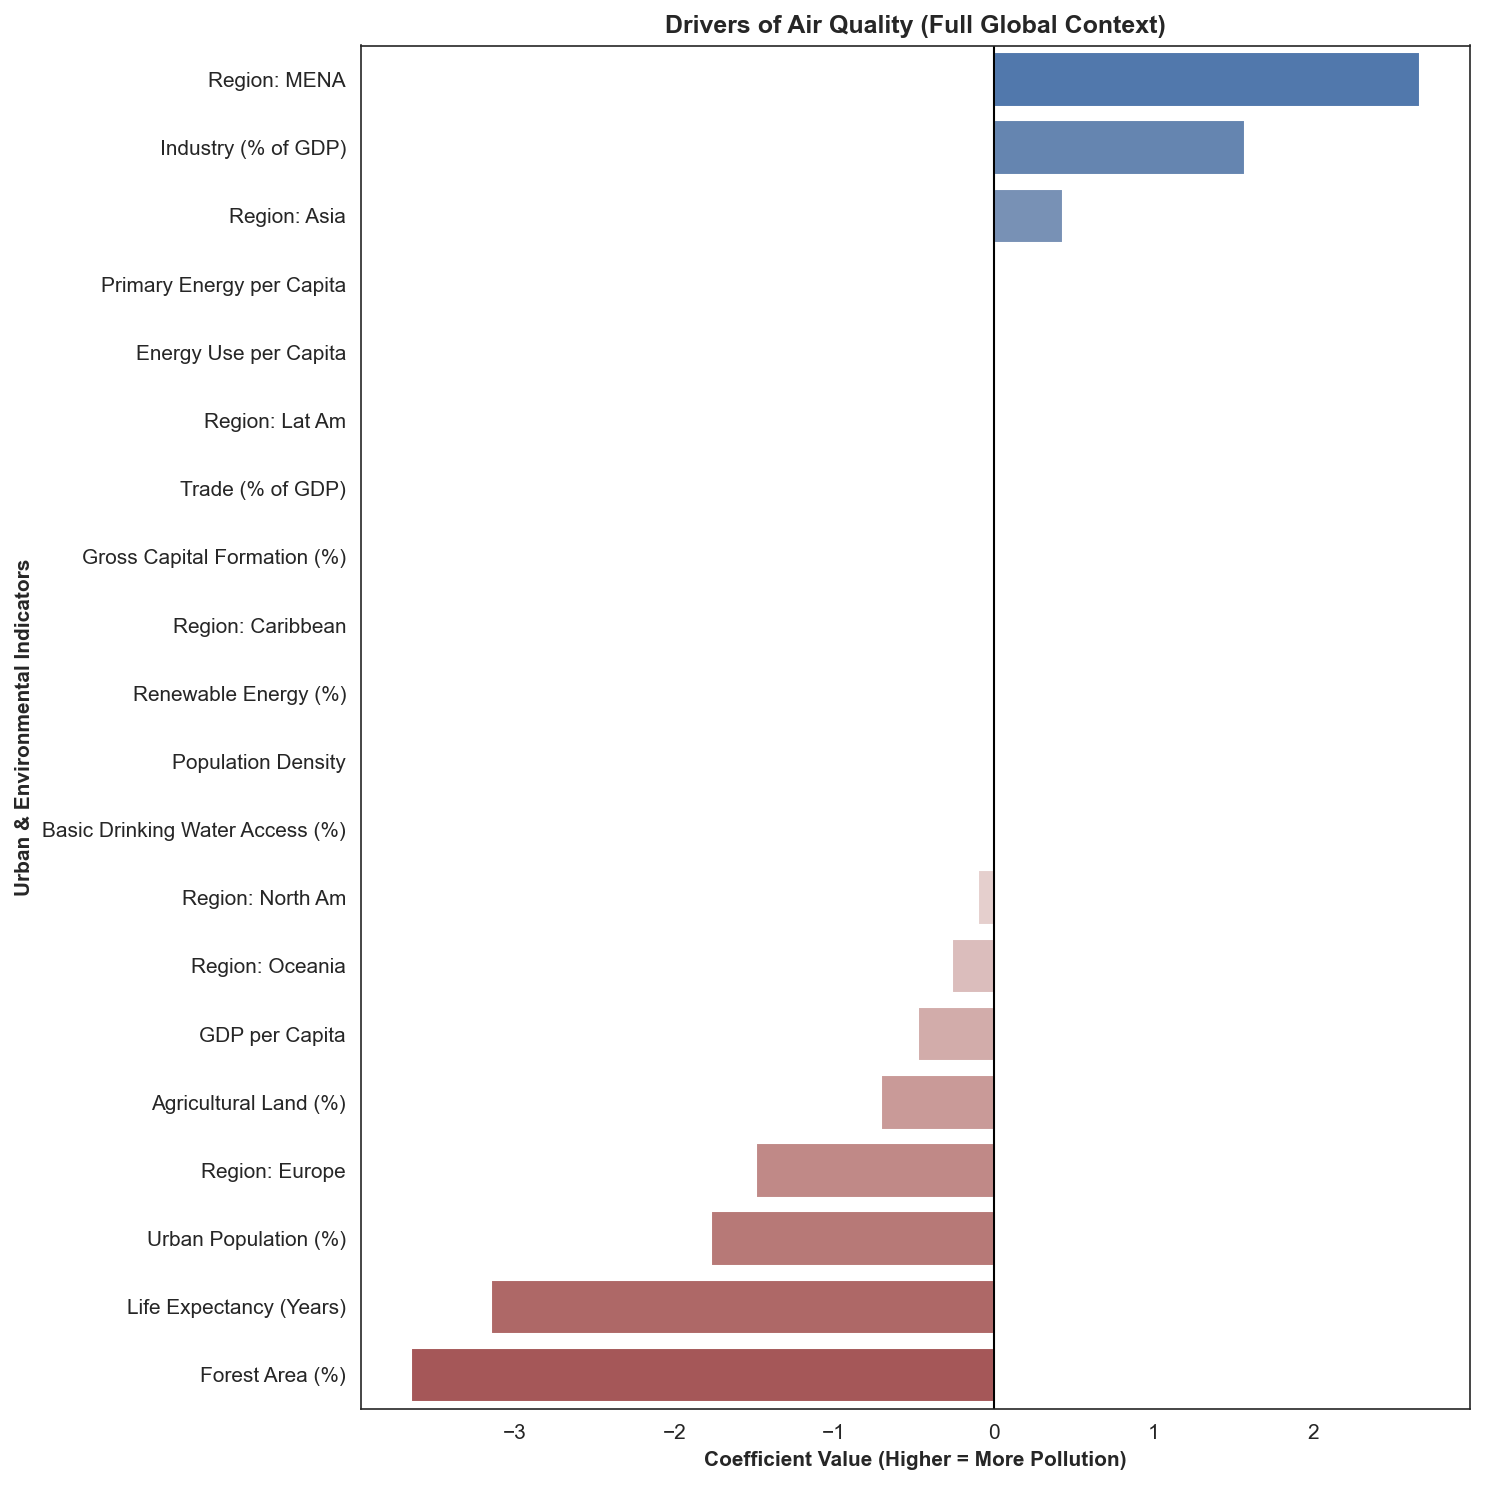

In [137]:
# Region: add it back
df['region'] = df['country'].map(region_map)
X_cols = list(feature_labels.keys())
model_df = df[['pm25', 'year', 'region'] + X_cols].dropna()

# One-Hot Encoding
model_df = pd.get_dummies(model_df, columns=['region'], drop_first=True)
features = [c for c in model_df.columns if c not in ['pm25', 'year']]

# Train test split 
train = model_df[model_df['year'] <= 2017]
test = model_df[model_df['year'] > 2017]
X_train, y_train = train[features], train['pm25']
X_test, y_test = test[features], test['pm25']

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


lasso = LassoCV(cv=5, random_state=42)
lasso.fit(X_train_scaled, y_train)
y_pred = lasso.predict(X_test_scaled)

print(f"Final LASSO (All Vars + Regions) R2: {r2_score(y_test, y_pred):.3f}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"Coeficients:" )
for f, c in zip(features, lasso.coef_):
    print(f"  {f}: {c:.3f}")

# 6. Plot (Reformat the region name for better display)
coef_df = pd.DataFrame({'Feature': features, 'Coef': lasso.coef_})
coef_df['Display Name'] = coef_df['Feature'].map(feature_labels).fillna(coef_df['Feature'])
coef_df['Display Name'] = coef_df['Display Name'].str.replace('region_', 'Region: ', regex=False)
coef_df['Display Name'] = coef_df['Display Name'].str.replace('.', '', regex=False) 

coef_df = coef_df.sort_values('Coef', ascending=False)

plt.figure(figsize=(10, 10), dpi=150)
sns.barplot(data=coef_df, x='Coef', y='Display Name', hue='Display Name', palette='vlag', legend=False)
plt.axvline(0, color='black', lw=1)
plt.title('Drivers of Air Quality (Full Global Context)', fontweight='bold')
plt.xlabel("Coefficient Value (Higher = More Pollution)", fontweight='bold')
plt.ylabel("Urban & Environmental Indicators", fontweight='bold')
plt.tight_layout()
# plt.show()
plt.savefig('f6.png', dpi=600)

### 2. Random Forest 

RANDOM FOREST RESULTS: 
R2 Score: 0.899
Mean Absolute Error: 3.29
RMSE (Penalty for Outliers): 5.11 µg/m³
Median Absolute Error: 2.06 µg/m³
MAPE (Percentage Error): 15.31%

Random Forest Feature Importances:
  forest_area_pct: 0.2930
  gdp_per_capita: 0.2586
  population_density: 0.0989
  basic_drinking_water_pct: 0.0772
  urban_population_pct: 0.0378
  renewable_energy_pct: 0.0346
  primary_energy_per_capita: 0.0342
  trade_pct_gdp: 0.0320
  life_expectancy: 0.0306
  industry_pct_gdp: 0.0282
  energy_use_per_capita: 0.0214
  agricultural_land_pct: 0.0202
  gross_capital_formation_pct: 0.0160
  region_MENA: 0.0128
  region_Europe: 0.0018
  region_Caribbean: 0.0012
  region_Asia: 0.0011
  region_Lat. Am.: 0.0005
  region_North Am.: 0.0000
  region_Oceania: 0.0000


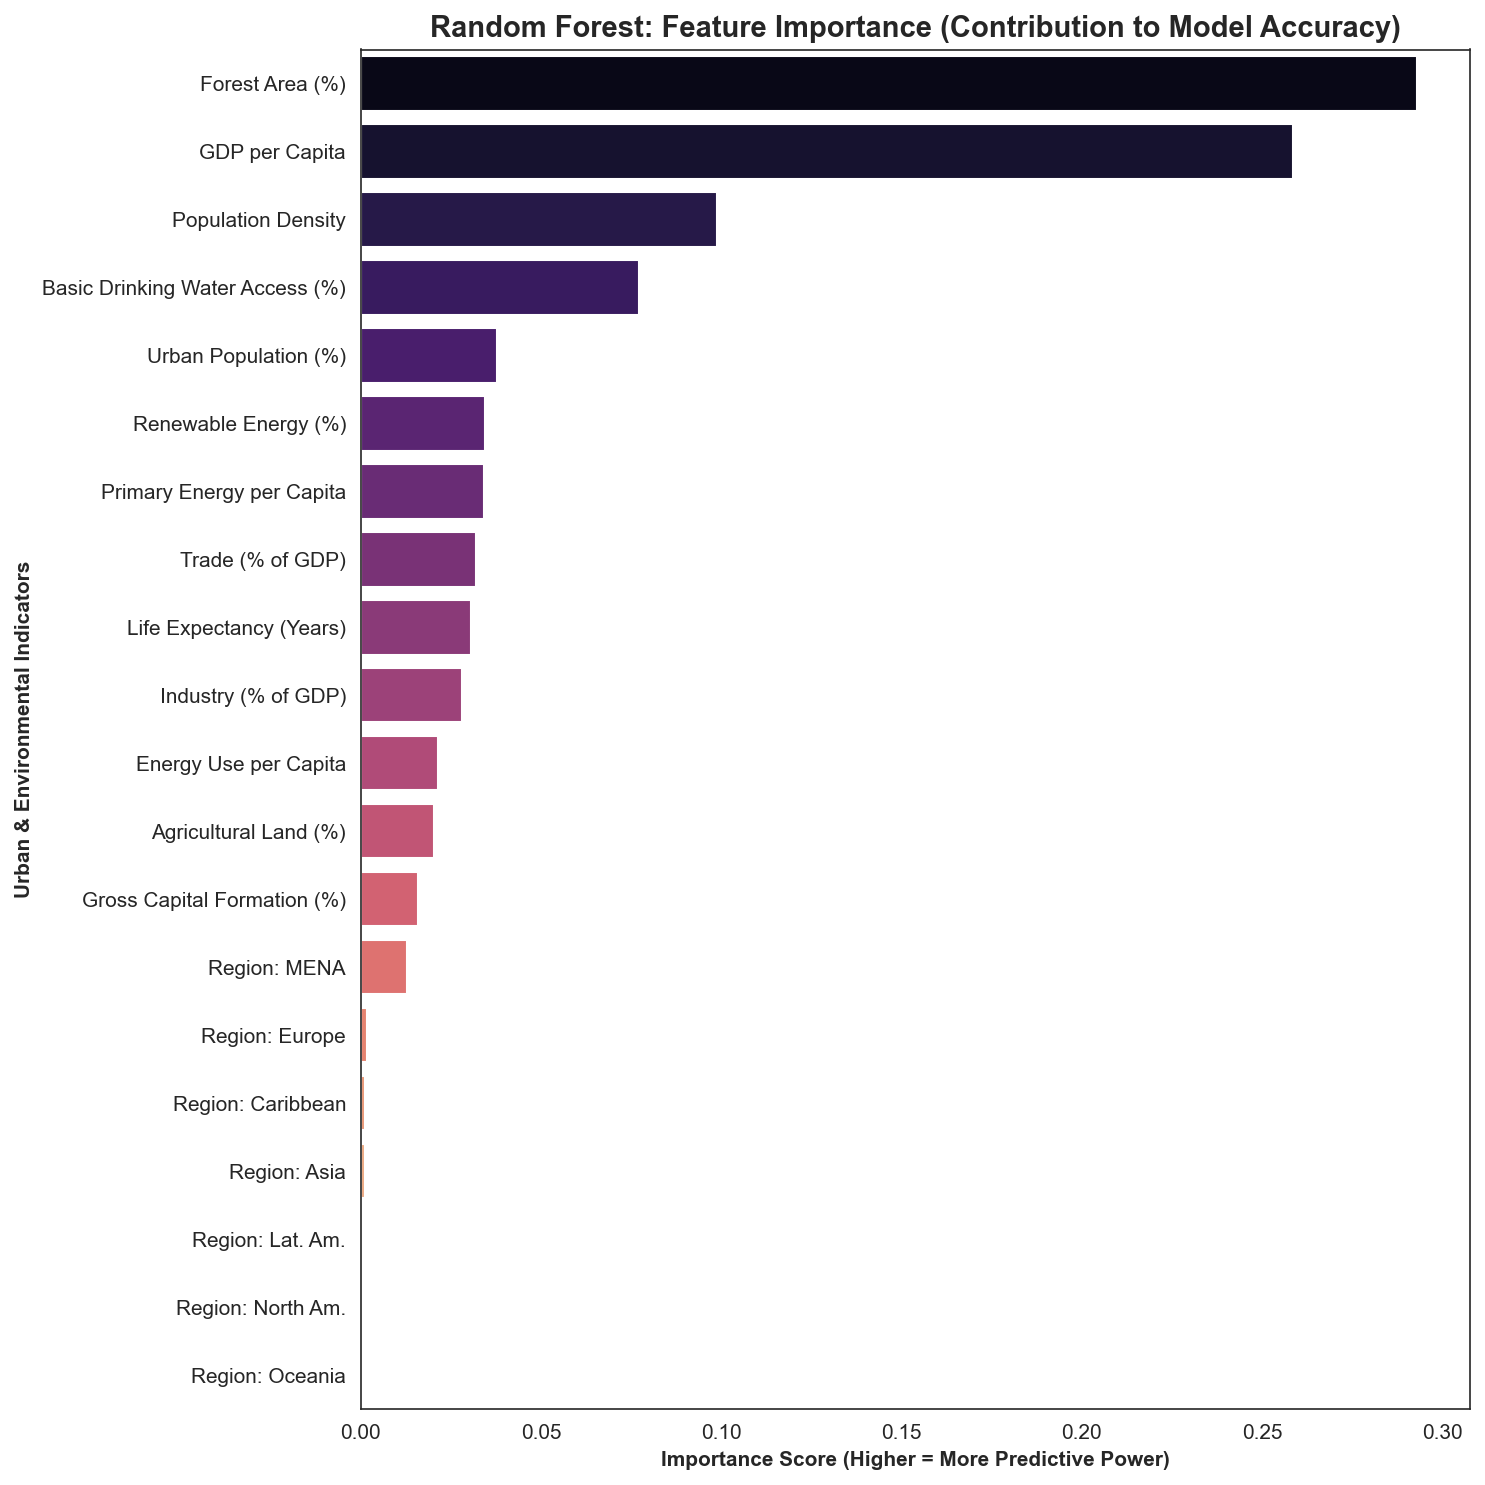

In [138]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, median_absolute_error, r2_score, mean_squared_error

features = [c for c in model_df.columns if c not in ['pm25', 'year']]

# Again, time-based Split (2008-2017 Training, 2018-2020 Testing)
train = model_df[model_df['year'] <= 2017]
test = model_df[model_df['year'] > 2017]

X_train, y_train = train[features], train['pm25']
X_test, y_test = test[features], test['pm25']


rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
rf_r2 = r2_score(y_test, y_pred)
rf_mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred)
med_ae = median_absolute_error(y_test, y_pred)

print(f"RANDOM FOREST RESULTS: ")
print(f"R2 Score: {rf_r2:.3f}")
print(f"Mean Absolute Error: {rf_mae:.2f}")
print(f"RMSE (Penalty for Outliers): {rmse:.2f} µg/m³")
print(f"Median Absolute Error: {med_ae:.2f} µg/m³")
print(f"MAPE (Percentage Error): {mape*100:.2f}%")
print("\nRandom Forest Feature Importances:")
importances = rf.feature_importances_
for f, imp in sorted(zip(features, importances), key=lambda x: x[1], reverse=True):
    print(f"  {f}: {imp:.4f}")
    

importances = rf.feature_importances_
rf_importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})

rf_importance_df['Display Name'] = rf_importance_df['Feature'].map(feature_labels).fillna(rf_importance_df['Feature'])
rf_importance_df['Display Name'] = rf_importance_df['Display Name'].str.replace('region_', 'Region: ', regex=False)

rf_importance_df = rf_importance_df.sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 10), dpi=150)
sns.barplot(data=rf_importance_df, x='Importance', y='Display Name', hue='Display Name', palette='magma', legend=False)
plt.title('Random Forest: Feature Importance (Contribution to Model Accuracy)', fontweight='bold', fontsize=14)
plt.xlabel("Importance Score (Higher = More Predictive Power)", fontweight='bold')
plt.ylabel("Urban & Environmental Indicators", fontweight='bold')
plt.tight_layout()
# plt.show()
plt.savefig('f7.png', dpi=600)

**Why Random Forest outperformed LASSO (R²: 0.42 → 0.90)** 

When switching from LASSO to Random Forest, the model performance improved a lot, with R-squared increasing from about 0.42 to 0.90. **This suggests that the relationship between sustainability indicators and PM2.5 is not purely linear.&& LASSO assumes that each variable has a fixed, additive effect on pollution. In reality, the effect of one variable may depend on another. For example, high population density might only lead to worse air quality when forest coverage is low or infrastructure is weak. Random Forest can capture these kinds of interactions and nonlinear patterns, which likely explains the large jump in explanatory power.


We also have lower MSE and MAE, which suggests that the Random Forest is not only explaining more variance but also making more accurate predictions on average. 


Now I decided to **drop regions**, since they seem to not be the main predictors as seen above. It seems that LASSO was using region as a significant indicator, but random forest is not.

The model’s performance stayed almost the same. This suggests that the sustainability variables already capture much of the regional variation. For instance, regions with high pollution may also systematically have lower forest coverage or different development patterns, so the model can infer those differences without needing an explicit region label.

PURE FACTOR RANDOM FOREST (No Regions): 
R2 Score: 0.900
Mean Absolute Error: 3.28
RMSE (Penalty for Outliers): 5.07 µg/m³
Median Absolute Error: 2.13 µg/m³
Mean Absolute Percentage Error: 15.66%

Random Forest Feature Importances:
  forest_area_pct: 0.3015
  gdp_per_capita: 0.2590
  population_density: 0.1018
  basic_drinking_water_pct: 0.0808
  urban_population_pct: 0.0395
  renewable_energy_pct: 0.0372
  primary_energy_per_capita: 0.0329
  trade_pct_gdp: 0.0322
  industry_pct_gdp: 0.0293
  life_expectancy: 0.0291
  agricultural_land_pct: 0.0210
  energy_use_per_capita: 0.0192
  gross_capital_formation_pct: 0.0165


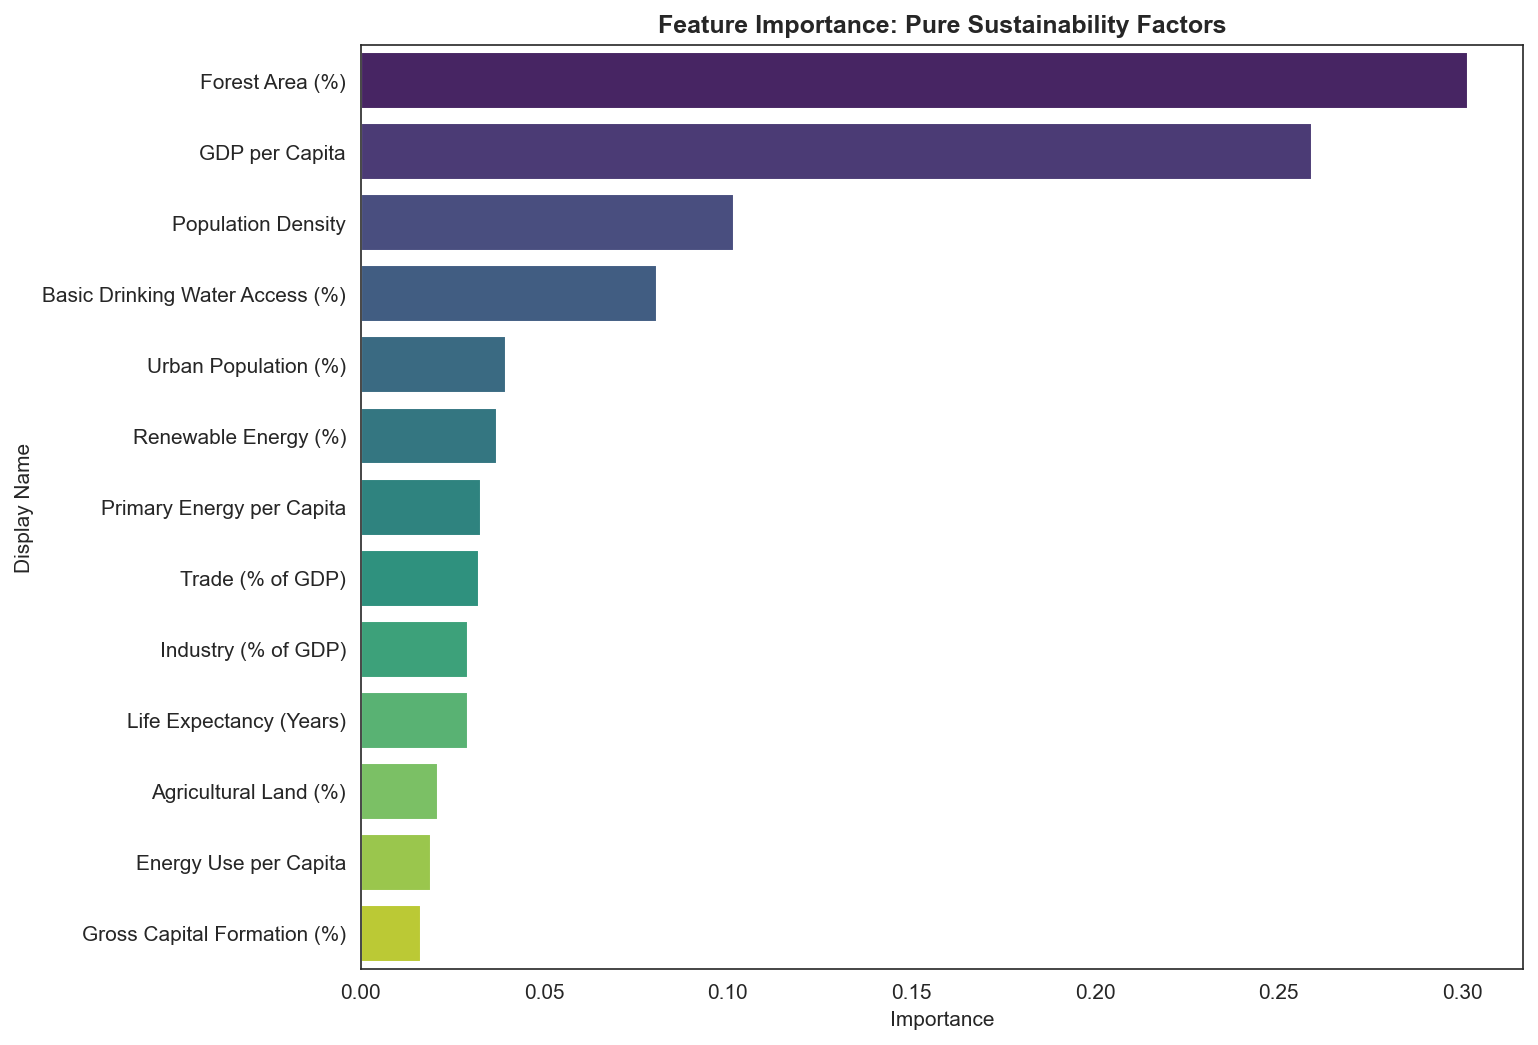

In [139]:
# Define only the sustainability features (Exclude all 'region_' columns)
pure_features = list(feature_labels.keys()) 


X_train_pure = train[pure_features]
X_test_pure = test[pure_features]
y_train, y_test = train['pm25'], test['pm25']

rf_pure = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_pure.fit(X_train_pure, y_train)

y_pred_pure = rf_pure.predict(X_test_pure)
pure_r2 = r2_score(y_test, y_pred_pure)
pure_mae = mean_absolute_error(y_test, y_pred_pure)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_pure))
mape = mean_absolute_percentage_error(y_test, y_pred_pure)
med_ae = median_absolute_error(y_test, y_pred_pure)

print(f"PURE FACTOR RANDOM FOREST (No Regions): ")
print(f"R2 Score: {pure_r2:.3f}")
print(f"Mean Absolute Error: {pure_mae:.2f}")
print(f"RMSE (Penalty for Outliers): {rmse:.2f} µg/m³")
print(f"Median Absolute Error: {med_ae:.2f} µg/m³")
print(f"Mean Absolute Percentage Error: {mape*100:.2f}%")
print("\nRandom Forest Feature Importances:")
importances = rf_pure.feature_importances_
for f, imp in sorted(zip(pure_features, importances), key=lambda x: x[1], reverse=True):
    print(f"  {f}: {imp:.4f}")

pure_importances = pd.DataFrame({
    'Feature': pure_features,
    'Importance': rf_pure.feature_importances_
}).sort_values('Importance', ascending=False)

pure_importances['Display Name'] = pure_importances['Feature'].map(feature_labels)

plt.figure(figsize=(10, 8), dpi=150)
sns.barplot(data=pure_importances, x='Importance', y='Display Name', hue='Display Name', palette='viridis', legend=False)
plt.title('Feature Importance: Pure Sustainability Factors', fontweight='bold')
# plt.show()
plt.savefig('f8.png', dpi=600)

### 3. Neural Networks 1: Multilayer Perceptron (MLP)

In [140]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error, median_absolute_error
from sklearn.neural_network import MLPRegressor

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train[pure_features])
X_test_scaled = scaler.transform(test[pure_features])

# 4 Layer Neural Network with ReLU activation and L2 regularization to prevent overfitting
nn_model = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32, 16), 
    activation='relu', 
    solver='adam', 
    alpha=0.01,         # L2 regularization for overfitting
    max_iter=3000,      
    learning_rate='adaptive', 
    random_state=42
)
nn_model.fit(X_train_scaled, y_train)


y_pred_nn = nn_model.predict(X_test_scaled)
nn_rmse = np.sqrt(mean_squared_error(y_test, y_pred_nn))
nn_med_ae = median_absolute_error(y_test, y_pred_nn)
nn_mape = mean_absolute_percentage_error(y_test, y_pred_nn)

print(f"NEURAL NETWORK RESULTS: ")
print(f"R2 Score: {r2_score(y_test, y_pred_nn):.3f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_nn):.2f} µg/m³")
print(f"RMSE (Penalty for Outliers): {nn_rmse:.2f} µg/m³")
print(f"Median Absolute Error: {nn_med_ae:.2f} µg/m³")
print(f"Mean Absolute Percentage Error: {nn_mape*100:.2f}%")

# Neural Network "Feature Importance" (Permutation Importance)
print("\nNeural Network Feature Importances (Permutation-based):")
result = permutation_importance(nn_model, X_test_scaled, y_test, n_repeats=10, random_state=42)
sorted_idx = result.importances_mean.argsort()[::-1]
for i in sorted_idx:
    print(f"  {pure_features[i]}: {result.importances_mean[i]:.4f}")

NEURAL NETWORK RESULTS: 
R2 Score: 0.924
MAE: 2.78 µg/m³
RMSE (Penalty for Outliers): 4.42 µg/m³
Median Absolute Error: 1.64 µg/m³
Mean Absolute Percentage Error: 12.50%

Neural Network Feature Importances (Permutation-based):
  gdp_per_capita: 0.5405
  forest_area_pct: 0.3985
  basic_drinking_water_pct: 0.3580
  life_expectancy: 0.3446
  energy_use_per_capita: 0.3083
  urban_population_pct: 0.2936
  renewable_energy_pct: 0.2853
  agricultural_land_pct: 0.2804
  primary_energy_per_capita: 0.1797
  industry_pct_gdp: 0.1043
  trade_pct_gdp: 0.0702
  gross_capital_formation_pct: 0.0678
  population_density: 0.0411


**The Neural Network: Capturing More Complex Patterns**

This model achieved the highest performance, with an **R-squared of 0.924**. Compared to Random Forest, the neural network is able to model more complex nonlinear relationships between the 13 sustainability indicators. It does not rely on simple splits or additive effects, and instead learns layered transformations of the data.

The neural network also had **a lower RMSE (4.42 µg/m³)**, which suggests it handled extreme pollution values more effectively. In other words, it was better at fitting both low and high pollution countries without being overly sensitive to outliers. Interestingly, variables like GDP per capita and energy use appeared especially important in this model, which may indicate that long run economic structure and energy intensity play a central role in shaping air quality outcomes.

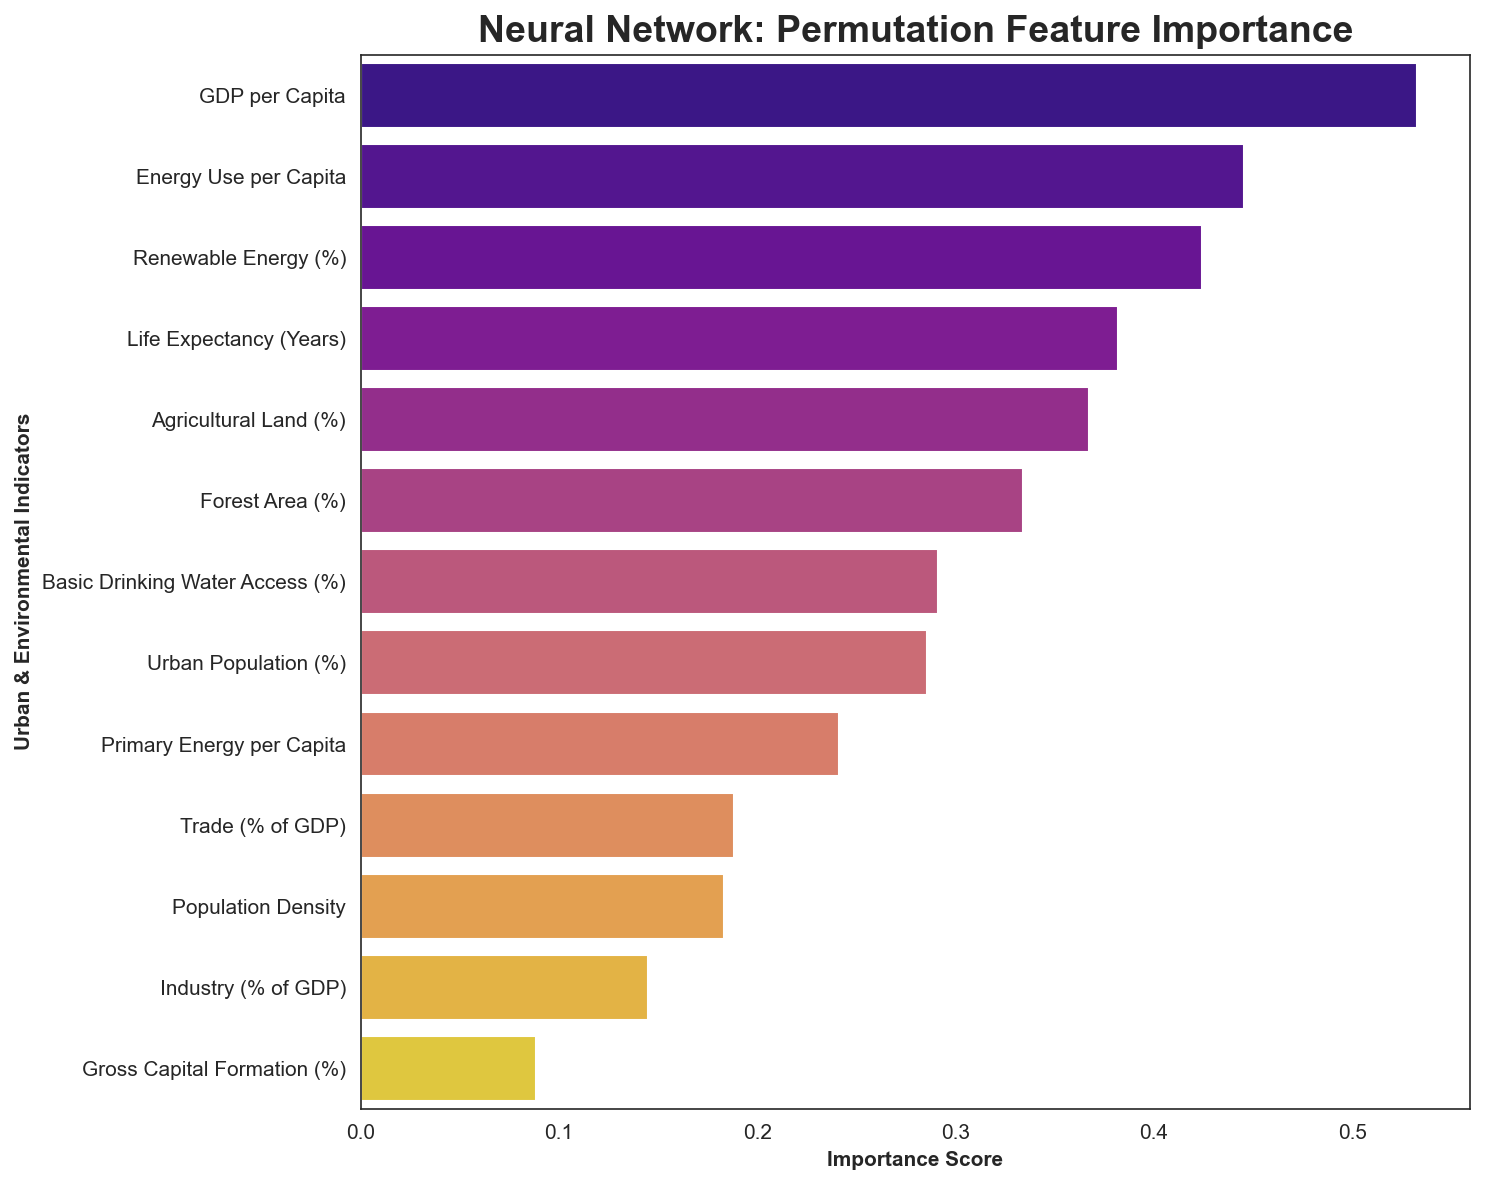

In [141]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

nn_data = {
    'gdp_per_capita': 0.5327,
    'energy_use_per_capita': 0.4452,
    'renewable_energy_pct': 0.4241,
    'life_expectancy': 0.3818,
    'agricultural_land_pct': 0.3672,
    'forest_area_pct': 0.3341,
    'basic_drinking_water_pct': 0.2909,
    'urban_population_pct': 0.2856,
    'primary_energy_per_capita': 0.2414,
    'trade_pct_gdp': 0.1882,
    'population_density': 0.1830,
    'industry_pct_gdp': 0.1449,
    'gross_capital_formation_pct': 0.0882
}

nn_imp_df = pd.DataFrame(list(nn_data.items()), columns=['Feature', 'Importance'])
nn_imp_df['Display Name'] = nn_imp_df['Feature'].map(feature_labels) 
nn_imp_df = nn_imp_df.sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 8), dpi=150)
sns.barplot(data=nn_imp_df, x='Importance', y='Display Name', hue='Display Name', palette='plasma', legend=False)
plt.title('Neural Network: Permutation Feature Importance', fontweight='bold', fontsize=18)
plt.xlabel('Importance Score', fontweight='bold')
plt.ylabel('Urban & Environmental Indicators', fontweight='bold')
plt.tight_layout()
# plt.show()
plt.savefig('f9.png', dpi=600)

### 3.5 Neural Networks MLP (Wider Architecture with Regularization)

To compare model complexity and speed, I tested two versions of an MLP: a deeper model with layers (128–64–32–16) and a wider model with a single 256 neuron layer, with 500 max iterations and early stopping to prevent overfitting. 

1. **Performance**
The deeper network performed better overall, reaching an R-squared of 0.924. This suggests that stacking multiple layers helps capture more complex nonlinear relationships in the data.

The wider network trained much faster, finishing in about 2 seconds, and still achieved an R-squared of 0.853. Even though it is simpler, it was able to explain a large portion of the variation.


2. **Feature Differences**
The deeper model placed more importance on GDP per capita, while the wider model emphasized life expectancy more strongly. This difference likely reflects how each architecture organizes and combines the inputs.

The deeper network gives the best predictive performance, but the wider model is a strong and efficient baseline.

/Users/chrislowzx/miniconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.



WIDE NEURAL NETWORK (FAST): 
Training Time: 1.2710 seconds
Stopped at iteration: 500
R2 Score: 0.853
MAE: 4.13 µg/m³

Wide NN Feature Importances:
  life_expectancy: 0.8704
  gdp_per_capita: 0.5446
  forest_area_pct: 0.2851
  basic_drinking_water_pct: 0.2851
  renewable_energy_pct: 0.2320
  energy_use_per_capita: 0.2239
  trade_pct_gdp: 0.1910
  urban_population_pct: 0.1896
  primary_energy_per_capita: 0.1823
  agricultural_land_pct: 0.1774
  industry_pct_gdp: 0.1188
  gross_capital_formation_pct: 0.1077
  population_density: 0.0313


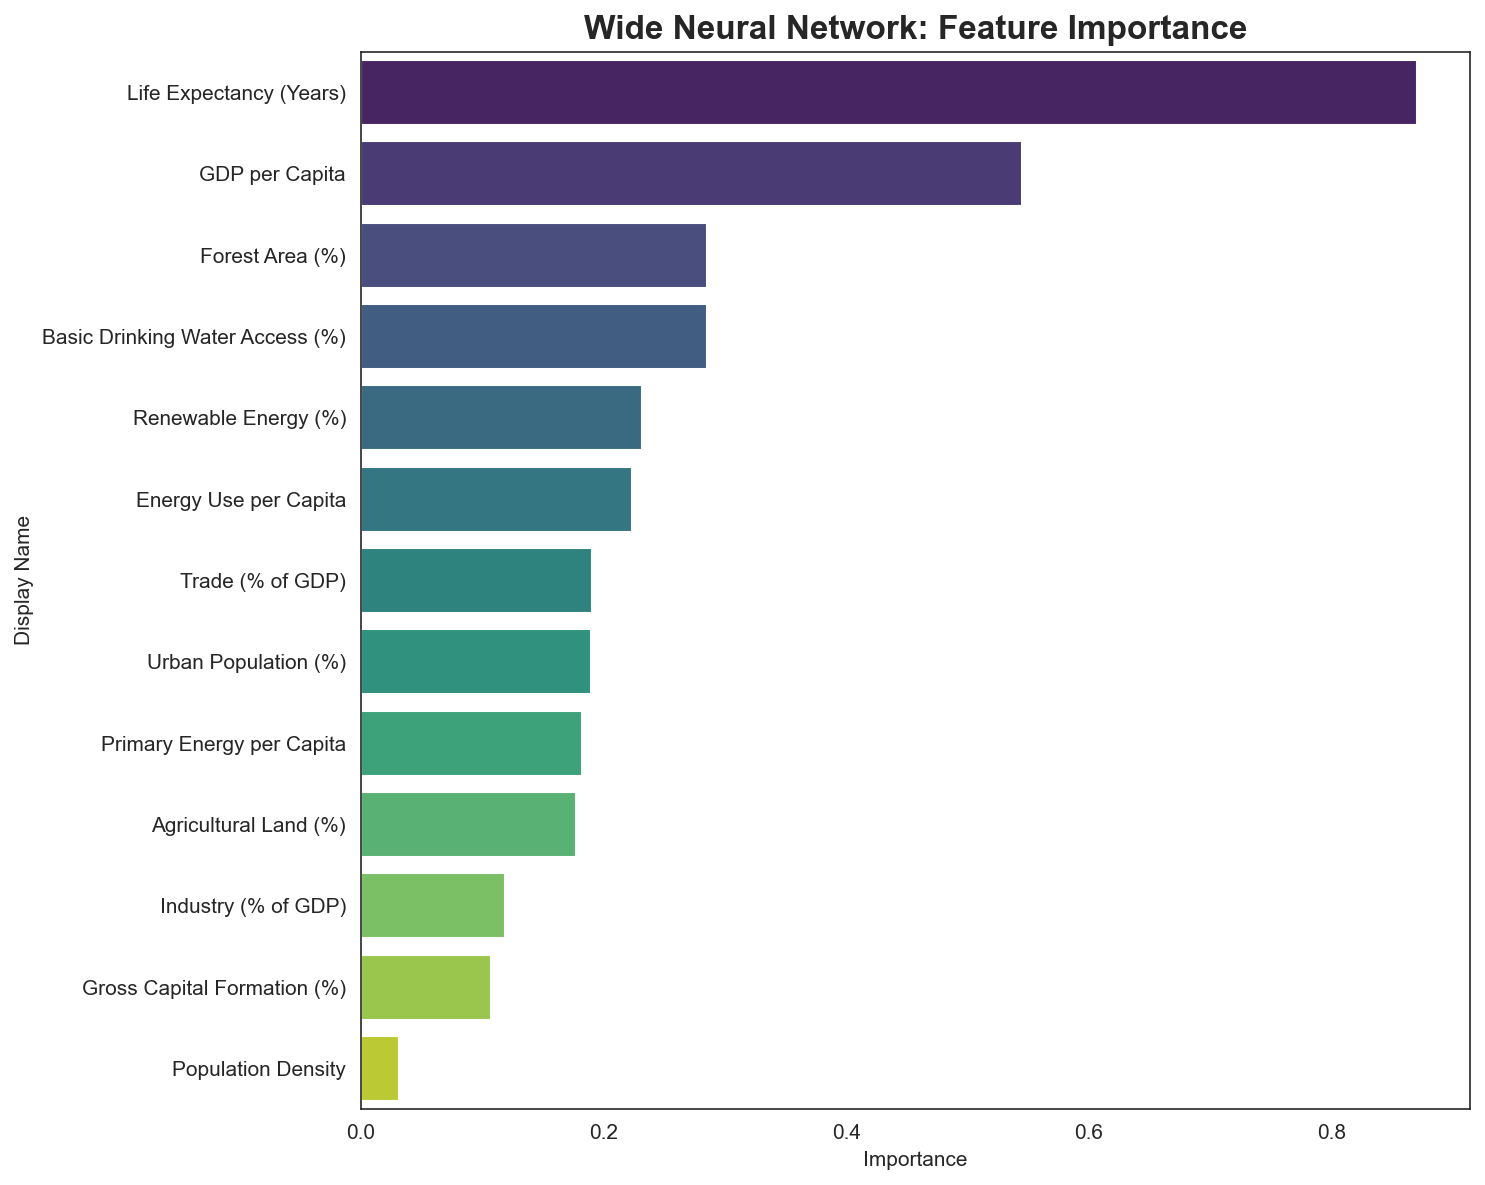

In [142]:
import time
from sklearn.metrics import mean_squared_error, median_absolute_error, r2_score, mean_absolute_error

scaler = StandardScaler()

X = df[pure_features]
y = df['pm25']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


start = time.time()
nn_fast = MLPRegressor(
    hidden_layer_sizes=(256,),  # Wide but shallow
    activation='relu', 
    solver='adam', 
    max_iter=500,        
    early_stopping=True,  # Speed up training 
    validation_fraction=0.1, 
    n_iter_no_change=10, 
    random_state=42
)
nn_fast.fit(X_train_scaled, y_train)
end = time.time()


y_pred_fast = nn_fast.predict(X_test_scaled)

print(f"WIDE NEURAL NETWORK (FAST): ")
print(f"Training Time: {end - start:.4f} seconds")
print(f"Stopped at iteration: {nn_fast.n_iter_}")
print(f"R2 Score: {r2_score(y_test, y_pred_fast):.3f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_fast):.2f} µg/m³")


print("\nWide NN Feature Importances:")
result_fast = permutation_importance(nn_fast, X_test_scaled, y_test, n_repeats=3, random_state=42)
sorted_idx_fast = result_fast.importances_mean.argsort()[::-1]
for i in sorted_idx_fast:
    print(f"  {pure_features[i]}: {result_fast.importances_mean[i]:.4f}")


# Plotting
fast_imp_data = []
for i in sorted_idx_fast:
    fast_imp_data.append({
        'Feature': pure_features[i],
        'Importance': result_fast.importances_mean[i]
    })

fast_imp_df = pd.DataFrame(fast_imp_data)
fast_imp_df['Display Name'] = fast_imp_df['Feature'].map(feature_labels)


plt.figure(figsize=(10, 8), dpi=150)
sns.barplot(data=fast_imp_df, x='Importance', y='Display Name', hue='Display Name', palette='viridis', legend=False)
plt.title('Wide Neural Network: Feature Importance', fontweight='bold', fontsize=16)
plt.tight_layout()
# plt.show()
plt.savefig('f10.png', dpi=600)

### 4. XGBoost


I compared Gradient Boosting (XGBoost) and a neural network (MLP). XGBoost performed well, achieving an $R^2$ of 0.884, which already indicates strong predictive power. However, the neural network performed slightly better, reaching an $R^2$ of 0.924 and a lower Mean Absolute Error of 2.78 µg/m³.

In [143]:
from xgboost import XGBRegressor


X_train_pure = train[pure_features]
X_test_pure = test[pure_features]
y_train, y_test = train['pm25'], test['pm25']

xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)
xgb_model.fit(X_train_pure, y_train) 

y_pred_xgb = xgb_model.predict(X_test_pure)
xgb_r2 = r2_score(y_test, y_pred_xgb)
xgb_mae = mean_absolute_error(y_test, y_pred_xgb)

print(f"XGBOOST RESULTS: ")
print(f"R2 Score: {xgb_r2:.3f}")
print(f"MAE: {xgb_mae:.2f} µg/m³")
print(f"MAPE: {mean_absolute_percentage_error(y_test, y_pred_xgb)*100:.2f}%")

XGBOOST RESULTS: 
R2 Score: 0.884
MAE: 3.50 µg/m³
MAPE: 15.91%



XGBoost Feature Importances (Gain-based):
  forest_area_pct: 0.2752
  gdp_per_capita: 0.2497
  basic_drinking_water_pct: 0.1271
  population_density: 0.1029
  trade_pct_gdp: 0.0377
  gross_capital_formation_pct: 0.0365
  urban_population_pct: 0.0322
  life_expectancy: 0.0307
  industry_pct_gdp: 0.0300
  agricultural_land_pct: 0.0233
  renewable_energy_pct: 0.0207
  energy_use_per_capita: 0.0191
  primary_energy_per_capita: 0.0149


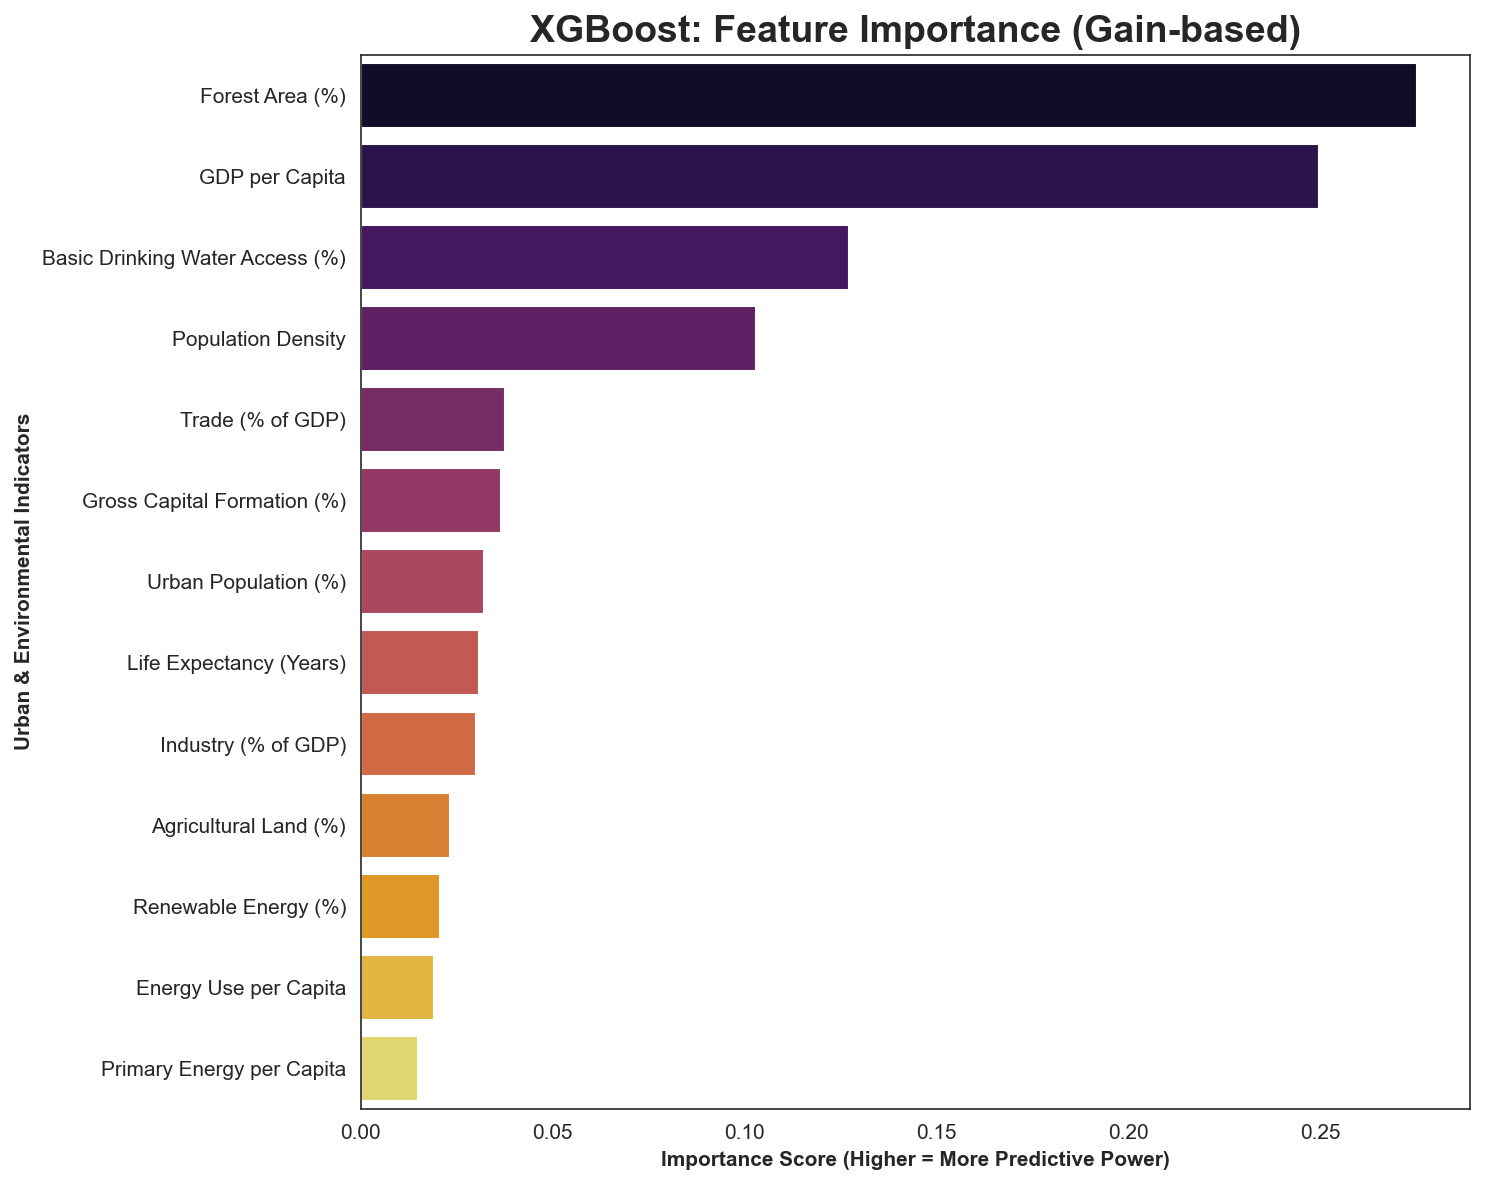

In [144]:
xgb_importances = pd.DataFrame({
    'Feature': pure_features,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

xgb_importances['Display Name'] = xgb_importances['Feature'].map(feature_labels)

print("\nXGBoost Feature Importances (Gain-based):")
for index, row in xgb_importances.iterrows():
    print(f"  {row['Feature']}: {row['Importance']:.4f}")


plt.figure(figsize=(10, 8), dpi=150)
sns.barplot(data=xgb_importances, x='Importance', y='Display Name', hue='Display Name', palette='inferno', legend=False)
plt.title('XGBoost: Feature Importance (Gain-based)', fontweight='bold', fontsize=18)
plt.xlabel('Importance Score (Higher = More Predictive Power)', fontweight='bold')
plt.ylabel('Urban & Environmental Indicators', fontweight='bold')
plt.tight_layout()
# plt.show()
plt.savefig('f11.png', dpi=600)

## **Part D: Dimensionality Reduction for Regression**

In [145]:
from sklearn.decomposition import PCA
import plotly.express as px 

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[pure_features])

# 3D first 
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

explained_var = pca.explained_variance_ratio_
total_var = sum(explained_var) * 100
print(f"Explained Variance by 3 Components: {total_var:.2f}%")
for i, var in enumerate(explained_var):
    print(f"  PC{i+1}: {var*100:.2f}%")


pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2', 'PC3'])
pca_df['pm25'] = df['pm25'].values
pca_df['Country'] = df['country'].values #

fig = px.scatter_3d(pca_df, x='PC1', y='PC2', z='PC3',
                    color='pm25', 
                    title=f"3D PCA: Latent Structure of Sustainability (Total Var: {total_var:.1f}%)",
                    labels={'pm25': 'Air Pollution'},
                    opacity=0.7)
# fig.show()
plt.savefig('f12.png', dpi=600)

Explained Variance by 3 Components: 58.02%
  PC1: 33.61%
  PC2: 13.93%
  PC3: 10.49%


<Figure size 960x720 with 0 Axes>

The first three PCs only capture about 58.02% of the variance, which is decent but not great. This suggests that while there are some underlying patterns, a lot of the variation in the data is still spread across multiple dimensions. 

#### Comparing both 3D and 2D

PCA REGRESSION TOURNAMENT: 
Full Feature Set (13 vars) R2: 0.900
Reduced 3D PCA Set (3 vars) R2: 0.777
Reduced 2D PCA Set (2 vars) R2: 0.603


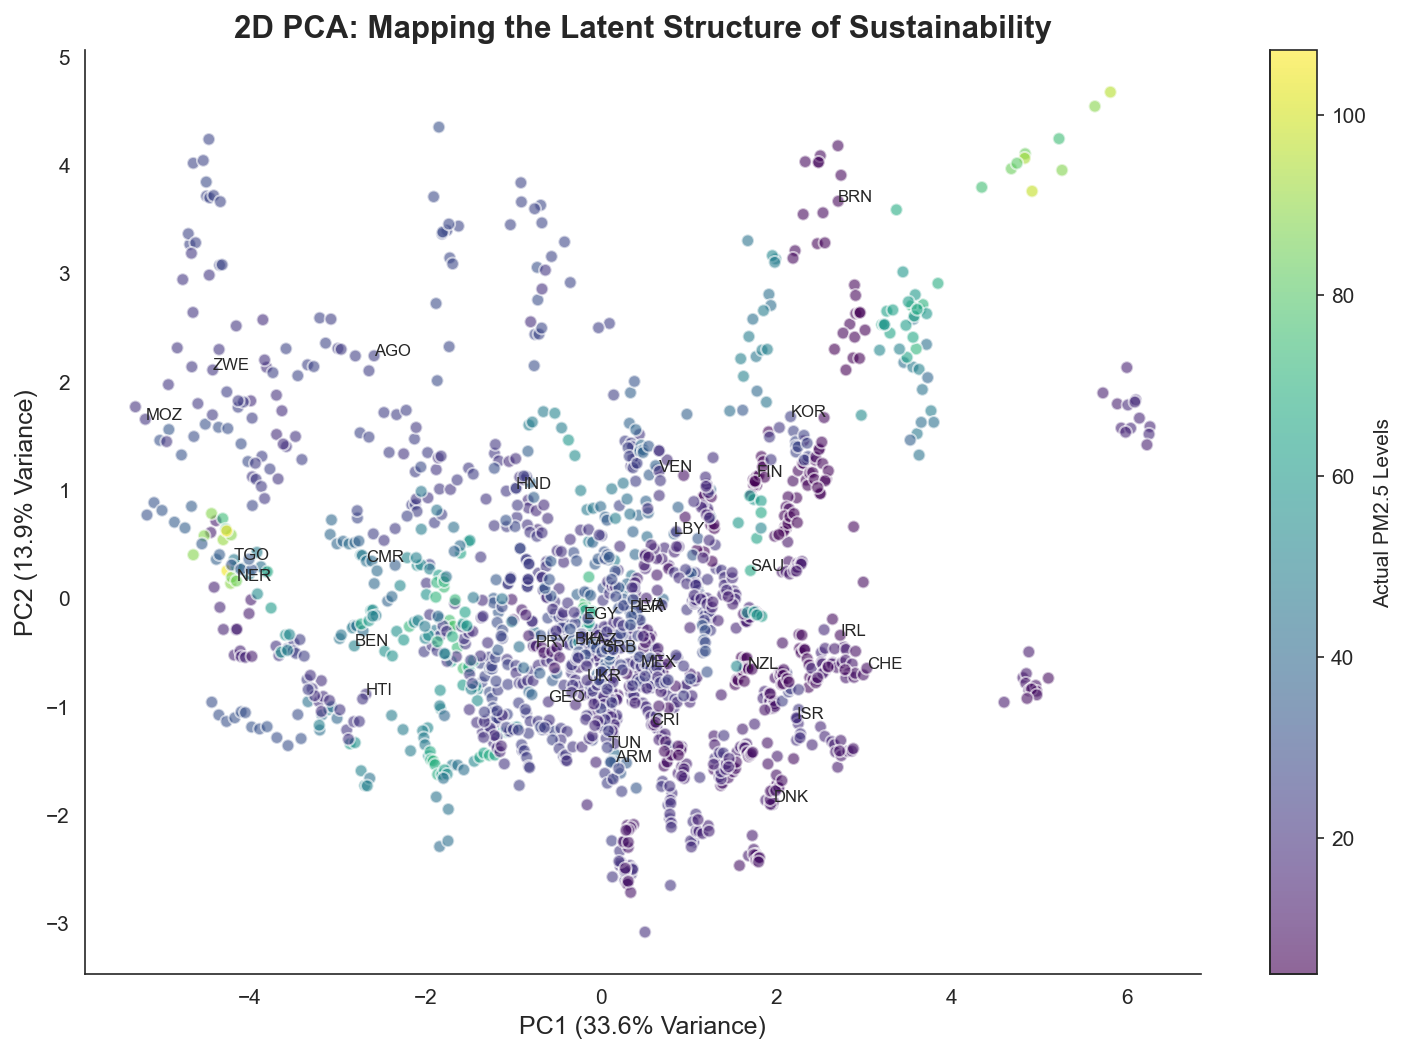

In [146]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[pure_features])

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)


pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2', 'PC3'])
pca_df['pm25'] = df['pm25'].values
pca_df['Region'] = df['region'].values 

# 2D VISUALIZATION (PC1 vs PC2)
plt.figure(figsize=(12, 8), dpi=150)
scatter = plt.scatter(pca_df['PC1'], pca_df['PC2'], 
            c=pca_df['pm25'], cmap='viridis', alpha=0.6, edgecolors='w')

plt.colorbar(scatter, label='Actual PM2.5 Levels')
plt.title('2D PCA: Mapping the Latent Structure of Sustainability', fontweight='bold', fontsize=15)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance)', fontsize=12)

for i, txt in enumerate(df['country']):
    if i % 50 == 0: # Label every 50th country for readability
        plt.annotate(txt, (pca_df['PC1'][i], pca_df['PC2'][i]), size=8)

sns.despine()
# plt.show()
plt.savefig('f13.png', dpi=600)

# PERFORMANCE TEST: 2D vs 3D vs FULL
from sklearn.ensemble import RandomForestRegressor

def get_rf_score(X_data, y_data):
    X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2, random_state=42)
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    return model.score(X_test, y_test)

score_full = 0.900 # From our previous run
score_3d = get_rf_score(X_pca, df['pm25'])
score_2d = get_rf_score(X_pca[:, :2], df['pm25'])

print(f"PCA REGRESSION TOURNAMENT: ")
print(f"Full Feature Set (13 vars) R2: {score_full:.3f}")
print(f"Reduced 3D PCA Set (3 vars) R2: {score_3d:.3f}")
print(f"Reduced 2D PCA Set (2 vars) R2: {score_2d:.3f}")

In [147]:
# Create a DataFrame of the PCA loadings
loadings = pd.DataFrame(
    pca.components_.T, 
    columns=['PC1', 'PC2', 'PC3'], 
    index=pure_features
)

# See which variables 'own' PC1
print("PC1 Top Loadings (The strongest drivers):")
print(loadings['PC1'].sort_values(ascending=False))

print("PC2 Top Loadings:")
print(loadings['PC2'].sort_values(ascending=False))

print("PC3 Top Loadings:")
print(loadings['PC3'].sort_values(ascending=False))

PC1 Top Loadings (The strongest drivers):
life_expectancy                0.423717
basic_drinking_water_pct       0.403232
urban_population_pct           0.399666
gdp_per_capita                 0.364288
energy_use_per_capita          0.340073
trade_pct_gdp                  0.228145
population_density             0.138679
industry_pct_gdp               0.077906
forest_area_pct               -0.026545
gross_capital_formation_pct   -0.033977
agricultural_land_pct         -0.156268
primary_energy_per_capita     -0.162308
renewable_energy_pct          -0.346128
Name: PC1, dtype: float64
PC2 Top Loadings:
industry_pct_gdp               0.490703
primary_energy_per_capita      0.418875
gross_capital_formation_pct    0.398589
energy_use_per_capita          0.292268
forest_area_pct                0.187522
renewable_energy_pct           0.132016
trade_pct_gdp                  0.128822
population_density             0.066618
gdp_per_capita                 0.027747
urban_population_pct           0.0

The 2D PCA plot mainly reflects the first two components, which line up closely with development (PC1) and industrial structure (PC2). Moving left to right along PC1, countries shift from lower infrastructure and quality of life toward higher life expectancy, better water access, and more urbanization. 

That horizontal spread looks like a development gradient. You can also see some pattern in the color shading. Countries further to the right often have lower PM2.5 levels, while many on the left show higher pollution, although it is not perfectly separated.


The vertical axis, PC2, captures how industrial a country’s economy is. Countries higher up tend to have larger industrial sectors and higher energy use. Those lower down lean more toward agriculture. 

So the map shows two main divides at once: development and industrial intensity. Even though PC3 is not shown here, it adds another layer related to forest cover and land use, which helps explain some of the remaining variation across countries. 

Overall, the plot suggests that sustainability patterns are shaped by a mix of development level, economic structure, and natural resources.


#### Scree Plot

PCA Explained Variance Table:
Component 1: Individual=33.61%, Cumulative=33.61%
Component 2: Individual=13.93%, Cumulative=47.53%
Component 3: Individual=10.49%, Cumulative=58.02%
Component 4: Individual=10.23%, Cumulative=68.25%
Component 5: Individual=9.12%, Cumulative=77.38%
Component 6: Individual=6.02%, Cumulative=83.40%
Component 7: Individual=4.27%, Cumulative=87.67%
Component 8: Individual=3.79%, Cumulative=91.46%
Component 9: Individual=2.92%, Cumulative=94.38%
Component 10: Individual=2.13%, Cumulative=96.51%
Component 11: Individual=1.52%, Cumulative=98.03%
Component 12: Individual=1.08%, Cumulative=99.11%
Component 13: Individual=0.89%, Cumulative=100.00%


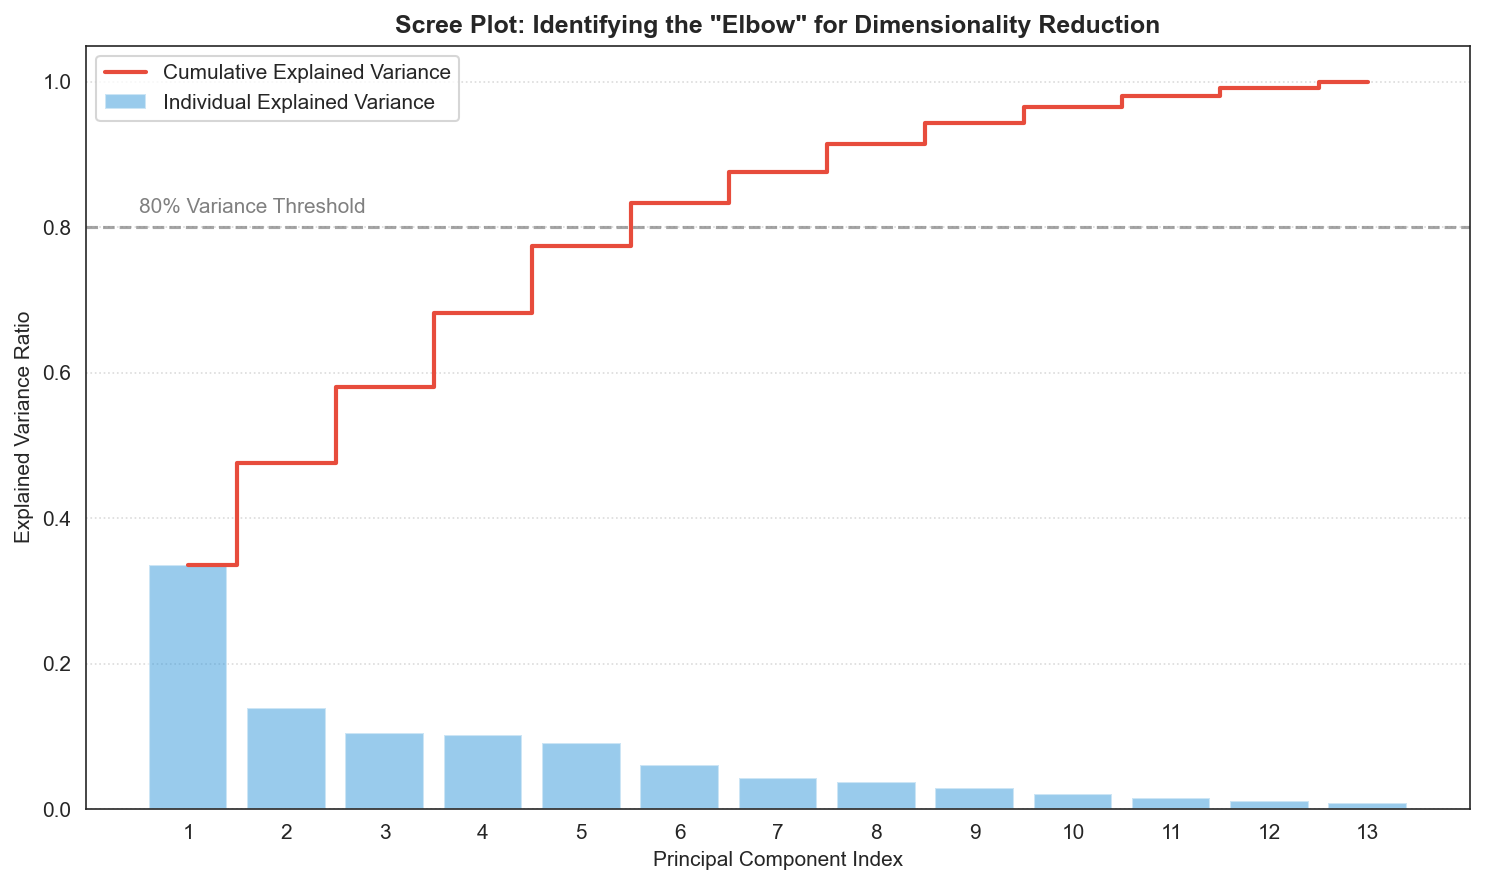

In [148]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[pure_features])


pca_full = PCA()
pca_full.fit(X_scaled)
exp_var_pca = pca_full.explained_variance_ratio_


cum_sum_eigenvalues = np.cumsum(exp_var_pca)


plt.figure(figsize=(10, 6), dpi=150)


plt.bar(range(1, len(exp_var_pca) + 1), exp_var_pca, alpha=0.5, align='center',
        label='Individual Explained Variance', color='#3498db')


plt.step(range(1, len(cum_sum_eigenvalues) + 1), cum_sum_eigenvalues, where='mid',
         label='Cumulative Explained Variance', color='#e74c3c', linewidth=2)


plt.axhline(y=0.80, color='grey', linestyle='--', alpha=0.7)
plt.text(0.5, 0.82, '80% Variance Threshold', color = 'grey', fontsize=10)

plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Component Index')
plt.title('Scree Plot: Identifying the "Elbow" for Dimensionality Reduction', fontweight='bold')
plt.xticks(range(1, 14))
plt.legend(loc='best')
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.tight_layout()
# plt.show()
plt.savefig('f14.png', dpi=600)


print("PCA Explained Variance Table:")
for i, (ind, cum) in enumerate(zip(exp_var_pca, cum_sum_eigenvalues)):
    print(f"Component {i+1}: Individual={ind:.2%}, Cumulative={cum:.2%}")

## **Part E: Dimensionality Reduction for Unsupervised Clustering**

/var/folders/vp/npcvxcc52xqfjgmswcdds6yc0000gn/T/ipykernel_32856/2887574440.py:14: UserWarning:

color is redundantly defined by the 'color' keyword argument and the fmt string "bo-" (-> color='b'). The keyword argument will take precedence.



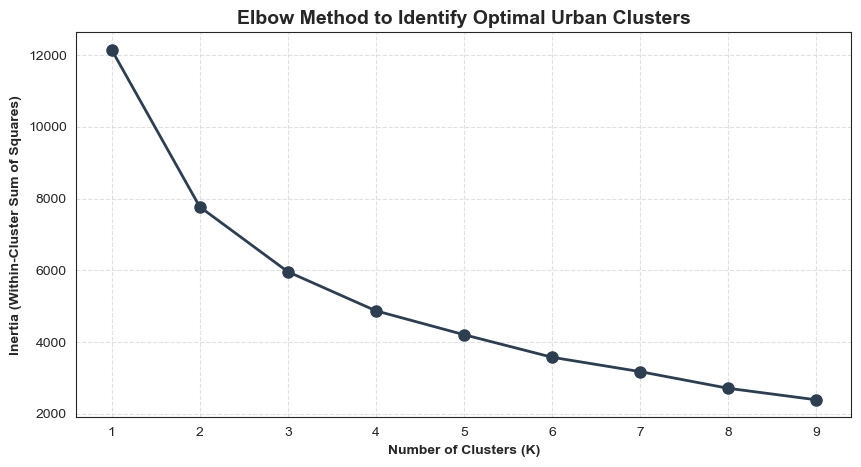

In [149]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# We use the 3 PCA components from Part D
inertia = []
K_range = range(1, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_pca)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 5), dpi=100)
plt.plot(K_range, inertia, 'bo-', markersize=8, linewidth=2, color='#2c3e50')
plt.xlabel('Number of Clusters (K)', fontweight='bold')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)', fontweight='bold')
plt.title('Elbow Method to Identify Optimal Urban Clusters', fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
# plt.show()
plt.savefig('f15.png', dpi=600)

From the elbow plot, it looks like the optimal number of clusters is around 3.

In [150]:
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_pca)

pca_df['Cluster'] = clusters
pca_df['Cluster'] = pca_df['Cluster'].astype(str) 

In [151]:
import plotly.express as px

# Cluster 0: Mid PC1, Low PC2 (Service Economies)
# Cluster 1: Low PC1, Mid PC2 (Developing/Forest-Rich)
# Cluster 2: High PC1, High PC2 (Industrial Giants)
cluster_map = {
    '0': 'Cluster 1: Post-Industrial/Service',
    '1': 'Cluster 2: Developing/High-Pollution',
    '2': 'Cluster 3: Industrialized/High-Growth'
}

pca_df['Cluster_Name'] = pca_df['Cluster'].map(cluster_map)

fig = px.scatter_3d(pca_df, x='PC1', y='PC2', z='PC3',
                    color='Cluster_Name', 
                    symbol='Cluster_Name',
                    hover_name=df['country'], 
                    title=f"Part E: 3D Cluster Visualization (K={optimal_k})",
                    labels={
                        'PC1': 'PC1: Modernization', 
                        'PC2': 'PC2: Industry', 
                        'PC3': 'PC3: Forests'
                    },
                    opacity=0.8)

fig.update_layout(
    title=dict(
        text=f"3D Cluster Visualization (K={optimal_k})",
        x=0.5,
        xanchor='center',
        y=0.93,
        yanchor='top',
        font=dict(size=20, family="Arial", color="black")
    ),
    legend=dict(
        title="Urban Profiles",
        x=0.8, 
        y=0.9,
        bgcolor="rgba(255,255,255,0.5)" 
    ),
    margin=dict(l=0, r=0, b=0, t=40),
    scene=dict(
        xaxis_title='PC1: Modernization',
        yaxis_title='PC2: Industry',
        zaxis_title='PC3: Forests'
    )
)

# fig.show()
plt.savefig('f16.png', dpi=600)

<Figure size 960x720 with 0 Axes>

In [152]:
cluster_summary = pca_df.groupby('Cluster').agg({
    'PC1': 'mean',
    'PC2': 'mean',
    'PC3': 'mean',
    'pm25': 'mean'
}).reset_index()

cluster_name_map = {
    0: 'Cluster 1: Post-Industrial (Cleanest)',
    1: 'Cluster 2: Developing (Highest Pollution)',
    2: 'Cluster 3: Industrialized (Moderate Pollution)'
}

cluster_summary['Cluster Name'] = cluster_summary['Cluster'].astype(int).map(cluster_name_map)

final_report_table = cluster_summary[['Cluster Name', 'PC1', 'PC2', 'PC3', 'pm25']].round(3)

final_report_table.columns = ['Urban Profile', 'PC1 (Modernization)', 'PC2 (Industry)', 'PC3 (Forests)', 'Avg PM2.5']

display(final_report_table)

,Urban Profile,PC1 (Modernization),PC2 (Industry),PC3 (Forests),Avg PM2.5
0,Cluster 1: Post-Industrial (Cleanest),0.384,-0.626,-0.040,22.391
1,Cluster 2: Developing (Highest Pollution),-2.748,0.636,0.184,35.666
2,Cluster 3: Industrialized (Moderate Pollution),2.836,1.410,-0.135,25.216


**Interpreting the PCA Clusters**

The three clusters line up well with the first three principal components. PC1 captures overall modernization development (life expectancy, water access, urbanization), PC2 reflects industrial intensity, and PC3 mainly represents forest cover.

Cluster 3 scores high on both PC1 and PC2. These are highly modernized and industrialized countries. Cluster 2 scores low on PC1 but relatively high on PC3. These tend to be less developed but more forest-rich countries (e.g. Gabon). Cluster 1 sits in the middle on development but has the lowest industrial intensity. These look like more service-oriented economies.

**Linking Clusters to PM2.5**

The pollution levels match this structure fairly well. Cluster 2 has the highest PM2.5, even though it has more forest cover. The likely reason is low modernization, meaning weaker infrastructure and emissions controls. Cluster 3 is industrial but more developed, so pollution is moderate. Cluster 1 has the lowest PM2.5, which aligns with its low industry score.

#### **Trying tSNE**

To try a different dimensionality reduction technique, I applied tSNE to the same data. The tSNE plot also shows a clear separation of clusters, but the axes are not interpretable like PCA. However, the overall grouping of countries is similar, confirming that the clusters are robust to different methods.

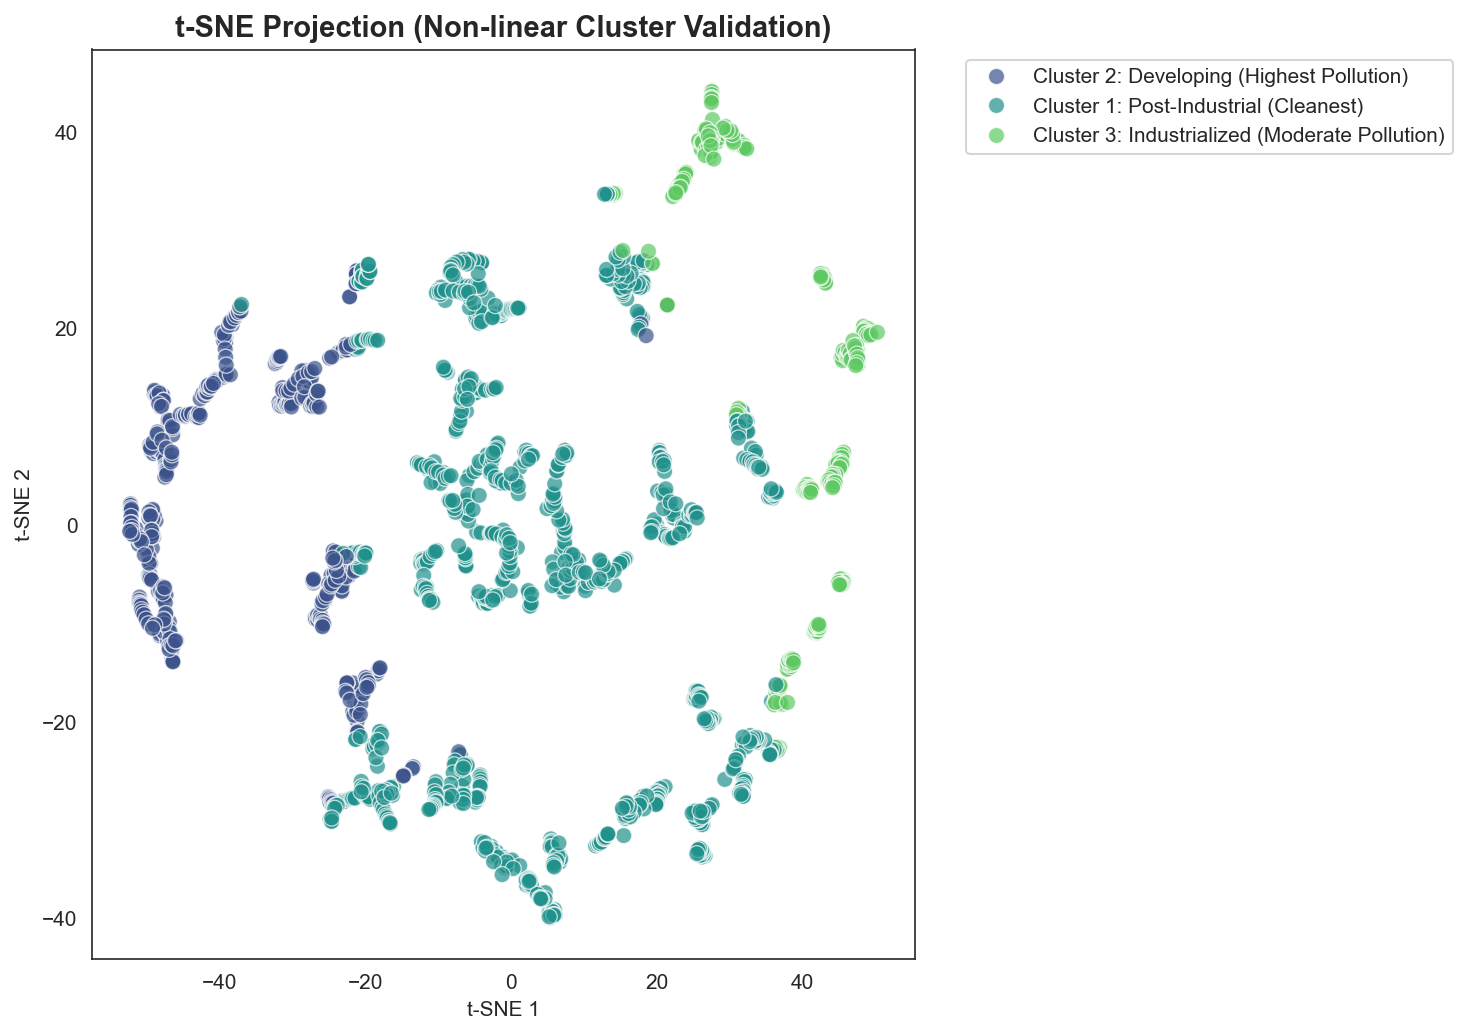

In [153]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X_pca) 


tsne_df = pd.DataFrame(X_tsne, columns=['t-SNE 1', 't-SNE 2'])
tsne_df['Cluster'] = clusters 

# Use the same cluster names as above
tsne_df['Cluster Name'] = tsne_df['Cluster'].astype(int).map(cluster_name_map)

plt.figure(figsize=(10, 7))
sns.scatterplot(data=tsne_df, x='t-SNE 1', y='t-SNE 2', 
                hue='Cluster Name', palette='viridis', s=60, alpha=0.7)

plt.title('t-SNE Projection (Non-linear Cluster Validation)', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
# plt.show()
plt.savefig('f17.png', dpi=600)

For clustering, I used K-Means with ($K = 3$) on the first three principal components. In the 3D PCA plot, the groups separate in a pretty clear way. One cluster scores high on modernization and industry. Another has lower development but relatively higher forest-related features. The third sits in the middle on development and stands out mainly for having low industrial intensity. The clusters are not perfectly clean, but they are structured enough to suggest there are real underlying patterns (as I explained it above).

The t-SNE plot shows a similar separation, even though it is a nonlinear projection. The same three groups appear as distinct regions rather than overlapping blobs. That makes the clustering feel more stable. When we compare them to PM2.5, the lower-development cluster has the highest pollution, the industrialized cluster is moderate, and the more service-based cluster is the cleanest. Overall, it looks like development level and industrial structure are more strongly tied to air quality than forest coverage by itself.


## **Part F: Cluster Analysis of Outcomes**

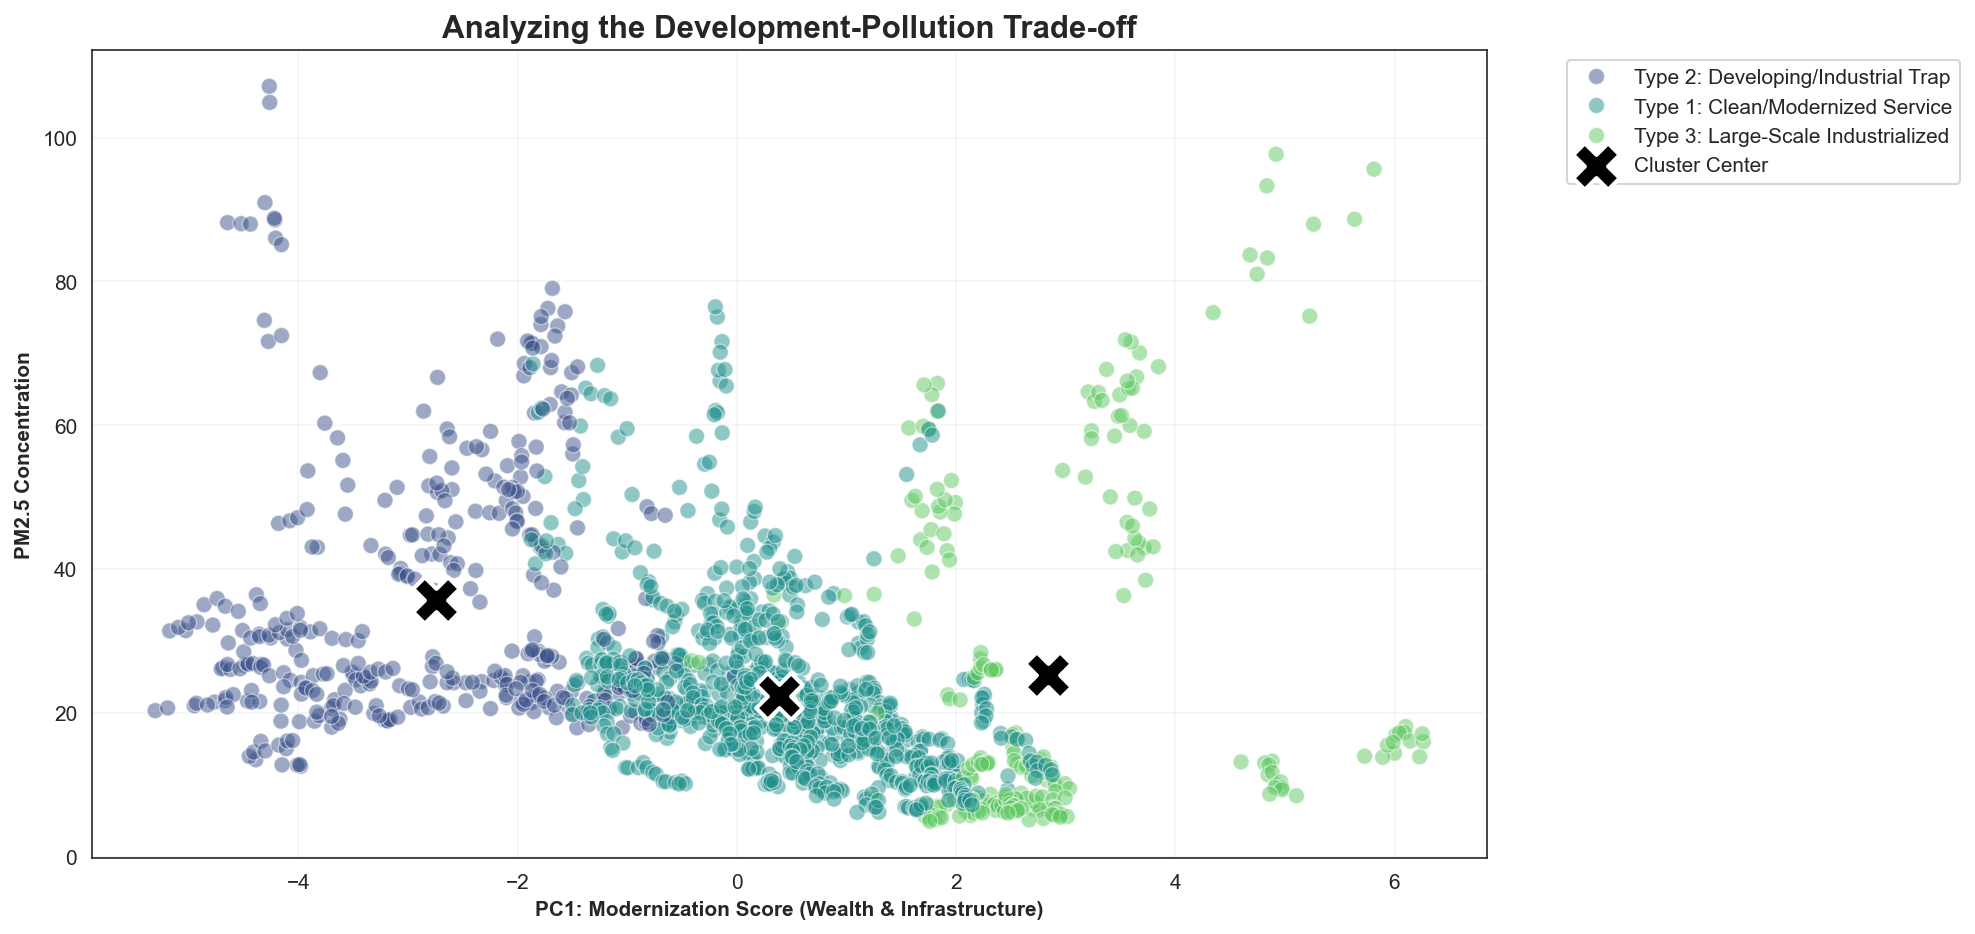

In [154]:
# 1. Attach the PC columns to your main dataframe
df['PC1'] = pca_df['PC1'].values
df['PC2'] = pca_df['PC2'].values
df['PC3'] = pca_df['PC3'].values

# 2. Attach the clusters and names
df['Cluster'] = clusters
cluster_name_map = {
    0: 'Type 1: Clean/Modernized Service',
    1: 'Type 2: Developing/Industrial Trap',
    2: 'Type 3: Large-Scale Industrialized'
}
df['Cluster Name'] = df['Cluster'].map(cluster_name_map)

# 3. Now the plot will work!
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))
sns.scatterplot(data=df, x='PC1', y='pm25', hue='Cluster Name', 
                palette='viridis', alpha=0.5, s=60)

# Add the cluster centers (means) for a professional finish
centers = df.groupby('Cluster Name').agg({'PC1':'mean', 'pm25':'mean'}).reset_index()
sns.scatterplot(data=centers, x='PC1', y='pm25', color='black', 
                s=500, marker='X', label='Cluster Center', edgecolor='white', linewidth=2)

plt.title('Analyzing the Development-Pollution Trade-off', fontsize=15, fontweight='bold')
plt.xlabel('PC1: Modernization Score (Wealth & Infrastructure)', fontweight='bold')
plt.ylabel('PM2.5 Concentration', fontweight='bold')
plt.grid(True, alpha=0.2)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.show()
plt.savefig('f18.png', dpi=600)

                         Cluster Name   pm25    USI
0    Type 1: Clean/Modernized Service  22.39  53.99
1  Type 2: Developing/Industrial Trap  35.67  49.56
2  Type 3: Large-Scale Industrialized  25.22  57.34


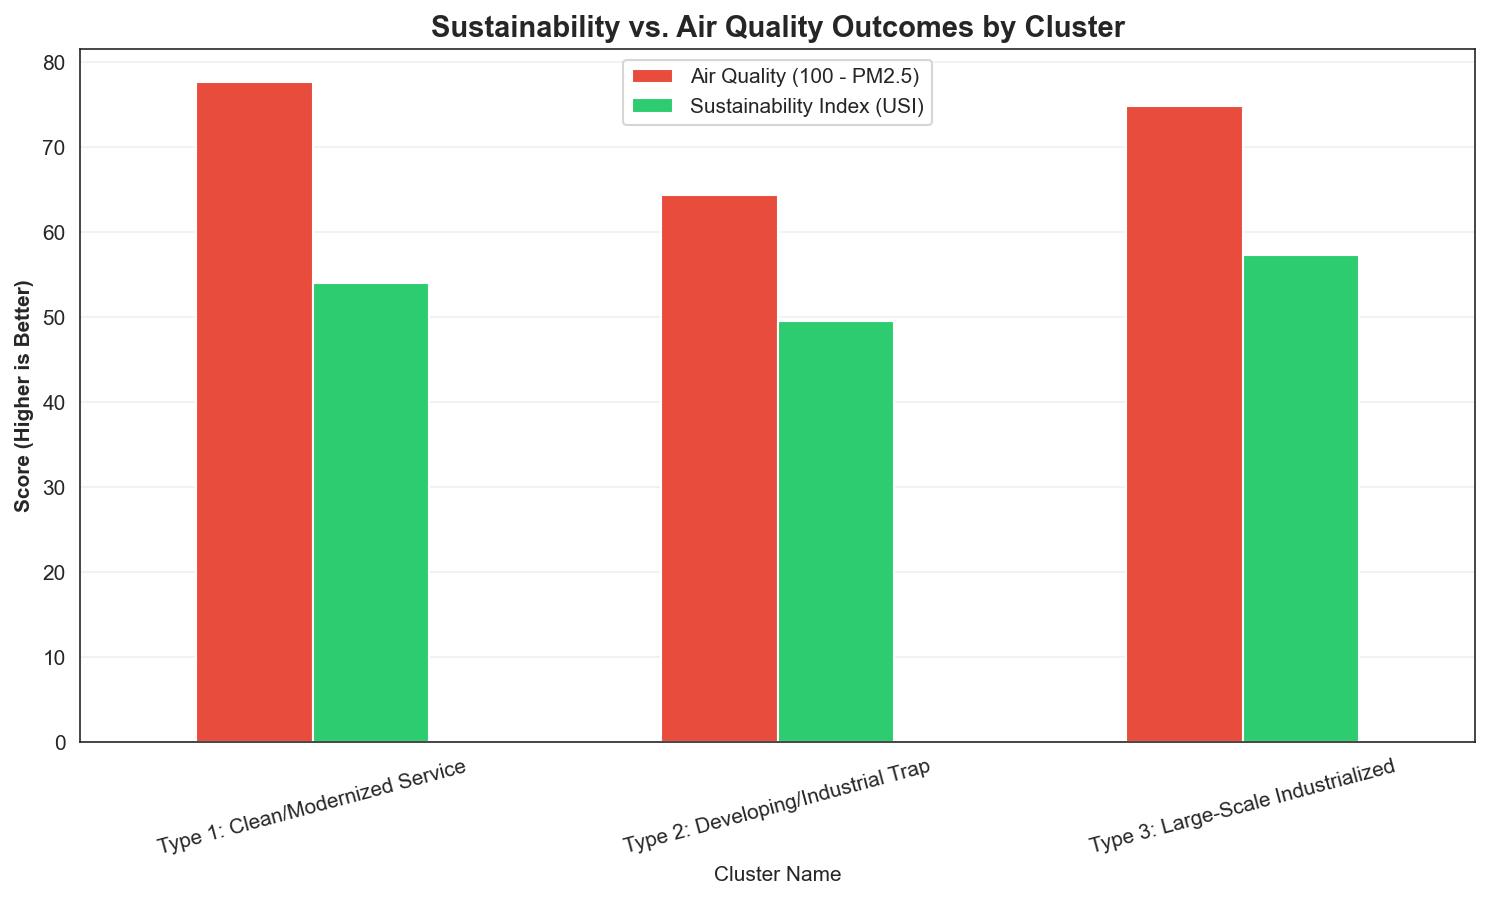

In [155]:
import matplotlib.pyplot as plt

analysis_f = df.groupby('Cluster Name').agg({
    'pm25': 'mean',
    'USI': 'mean'
}).reset_index().round(2)

print(analysis_f)

outcomes_plot = analysis_f.copy()
outcomes_plot['PM2.5 (Inverted)'] = 100 - outcomes_plot['pm25'] # Lower pollution = higher bar

outcomes_plot.plot(x='Cluster Name', y=['PM2.5 (Inverted)', 'USI'], 
                   kind='bar', figsize=(12, 6), color=['#e74c3c', '#2ecc71'])

plt.title('Sustainability vs. Air Quality Outcomes by Cluster', fontsize=14, fontweight='bold')
plt.ylabel('Score (Higher is Better)', fontweight='bold')
plt.xticks(rotation=15)
plt.legend(['Air Quality (100 - PM2.5)', 'Sustainability Index (USI)'])
plt.grid(axis='y', alpha=0.3)
# plt.show()
plt.savefig('f19.png', dpi=600)

The three clusters show clear differences in both sustainability and air quality. **Type 1 (Clean/Modernized Service) has the lowest pollution and a moderate Sustainability Index score.** These countries look more service-oriented, with lower industrial intensity, which likely explains their cleaner air. They are not the highest on the sustainability index, but they appear relatively balanced.

**Type 2 (Developing/Industrial Trap) stands out as the most polluted group.** It also has the lowest Sustainability Index score. This makes sense since these countries tend to have lower modernization and weaker infrastructure, which can lead to higher emissions and fewer environmental protections.

**Type 3 (Large-Scale Industrialized) has the highest Sustainability Index but slightly higher pollution compared to Type 1.** Part of this may be driven by GDP per capita and life expectancy, which increase the USI score as I defined in part A. So while these countries are economically strong and score well on development metrics, industrial activity still contributes to pollution. Over time, their higher income levels and life expectancy might allow for cleaner technologies, but right now they sit in the middle in terms of air quality.

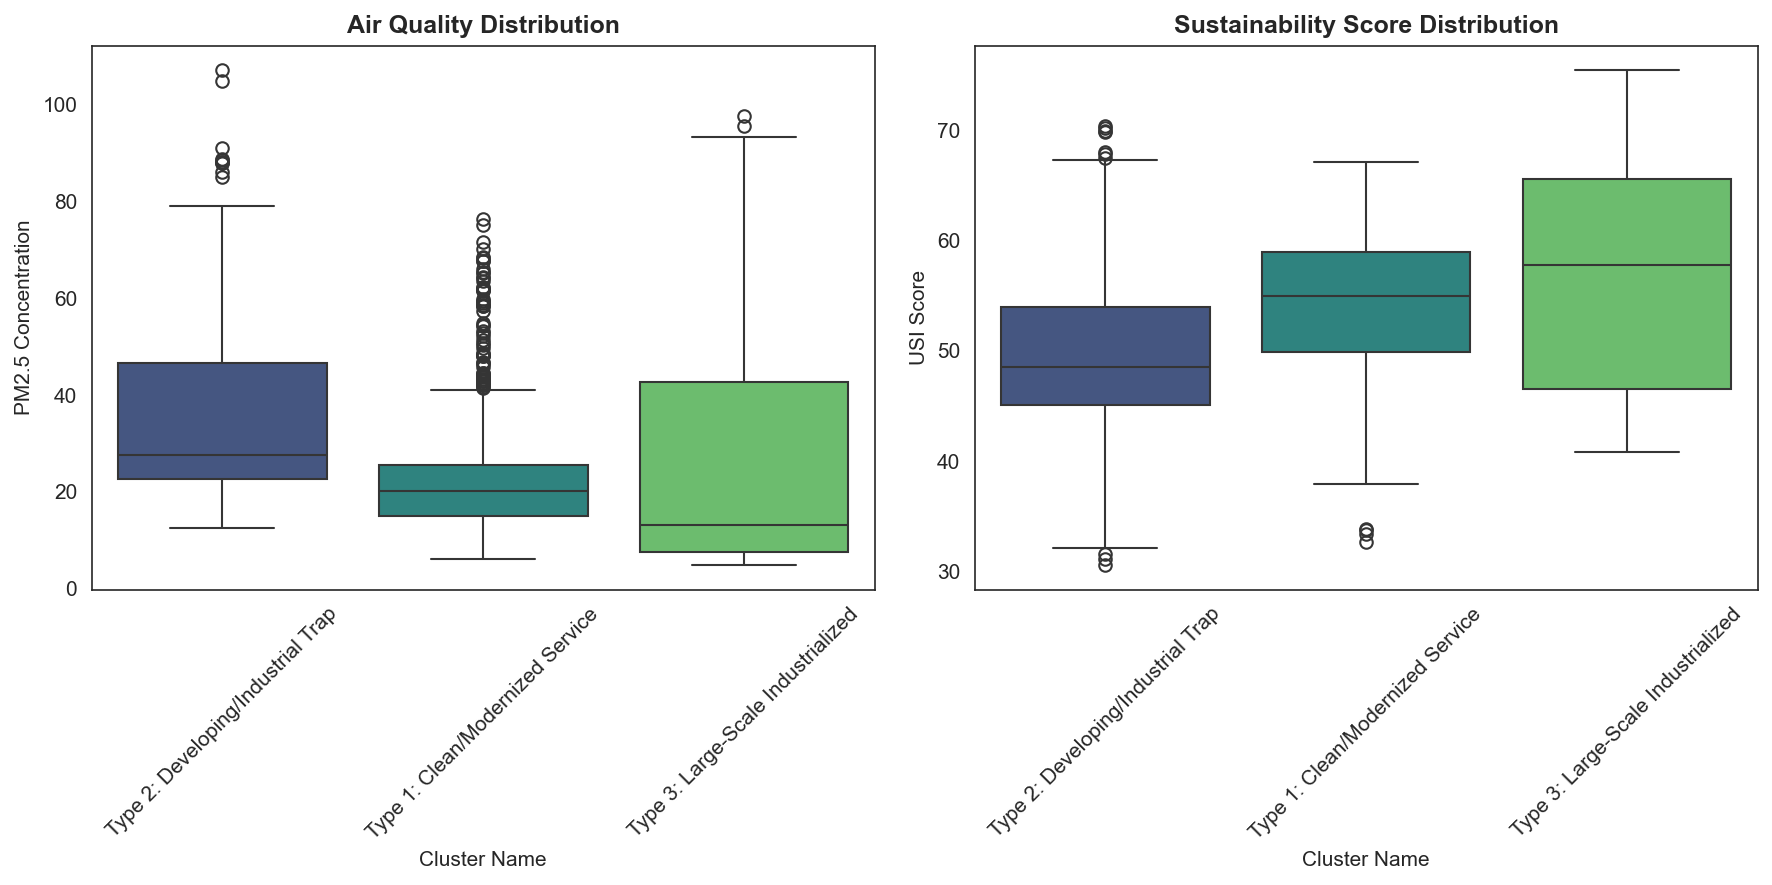

In [156]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# PM2.5
plt.subplot(1, 2, 1)
sns.boxplot(
    data=df,
    x='Cluster Name',
    y='pm25',
    hue='Cluster Name',   
    palette='viridis',
    legend=False          
)
plt.title('Air Quality Distribution', fontweight='bold')
plt.ylabel('PM2.5 Concentration')
plt.xticks(rotation=45)

# USI
plt.subplot(1, 2, 2)
sns.boxplot(
    data=df,
    x='Cluster Name',
    y='USI',
    hue='Cluster Name',   
    palette='viridis',
    legend=False
)
plt.title('Sustainability Score Distribution', fontweight='bold')
plt.ylabel('USI Score')
plt.xticks(rotation=45)

plt.tight_layout()
# plt.show()
plt.savefig('f20.png', dpi=600)

The boxplots help confirm that the differences between clusters are not just driven by a few extreme observations. In the PM2.5 plot, Type 2 (Developing/Industrial Trap) clearly has a higher median and a wider spread, with several high outliers. This shows that pollution is not only higher on average but also more variable within that group. Type 1 (Clean/Modernized Service) has a lower median and a tighter box, suggesting more consistent air quality. Type 3 (Large-Scale Industrialized) sits in between, with moderate pollution but still some extreme cases.

In the Sustainability Index plot, Type 3 has the highest median USI, which shows that it's strongest economically and has the potential to be sustainable. Type 1 is slightly lower but still relatively stable, while Type 2 has the lowest median and more lower-end outliers. 


Taken together, the plots highlight: **Type 2 struggles with both high pollution and lower sustainability capacity, whereas Type 3 combines high development with moderate pollution (and high potential to be more sustainable in the future). Type 1 appears the most balanced, with cleaner air and steady sustainability performance.**


## **Part G: Reflection on Modeling and Overfitting**

Training a very large number of models and selecting the one with the highest $R^2$ can create a classic data snooping problem. If you try enough combinations, one model will eventually look excellent just by chance. This often leads to overfitting the validation set, where the model unintentionally “learns” the quirks of that specific split rather than the true relationship between sustainability indicators and PM2.5. It can also produce spurious correlations, where the model captures noise that will not generalize to new data. In addition, the top-performing model in a large search is often the most complex, which reduces interpretability and increases the risk of poor real-world performance.

To reduce these risks, I used a clear train–test split and avoided repeatedly tuning against the same validation slice. Dimensionality reduction through PCA helped limit redundancy and noise in the feature space, which reduces the temptation to overfit highly correlated variables. Regularization further constrained model complexity, encouraging simpler and more stable relationships. Finally, the clustering analysis in Part E serves as a qualitative check: the fact that clusters align with meaningful economic and environmental patterns suggests the models are capturing real structure in the data rather than just optimizing a metric.
